# Movie Data Pipeline Demo

This notebook demonstrates the complete data acquisition and cleaning pipeline for the Rotten Tomatoes and IMDB movie analysis project. We'll use the automated task system to download datasets, clean the data, and scrape additional movie information from Rotten Tomatoes.

## Project Overview

This project analyzes movie reviews and ratings data from Rotten Tomatoes and IMDB.

### Demo Steps

1. **Environment Setup**: Install dependencies and verify setup
2. **Data Download**: Download raw datasets from Kaggle
3. **Data Cleaning**: Clean and validate the downloaded data
4. **Web Scraping**: Scrape additional movie details from Rotten Tomatoes
5. **Data Exploration**: Validate and explore the final cleaned datasets
6. **Methodology**: Demonstrate various analysis methods on the cleaned data
    1. Frequent items
    2. Sentence embeddings
    3. Graph analysis
    4. Collaborative filtering

# Setup task and uv 

Task is a Python library for automating data workflows. uv is a command-line tool for managing and executing these tasks.

Task installation guide can be found at: https://taskfile.dev/installation/
- Windows: `winget install Task.Task`

uv installation guide can be found at: https://docs.astral.sh/uv/getting-started/installation/
- Windows: `powershell -c "irm https://astral.sh/uv/install.ps1 | more"`

## 1. Environment Setup

Install virtuel environment with uv using *pyproject.toml*

In [4]:
# Sync dependencies using uv
!uv sync

Resolved 164 packages in 1ms
Audited 143 packages in 0.05ms


Let's verify that our environment is properly set up and all dependencies are installed.

In [5]:
# Check Python version and environment
import sys
print(f"Python version: {sys.version}")
print(f"Current working directory: {sys.path[0]}")

# Verify required packages are available
try:
    import polars as pl
    import pandas as pd
    import numpy as np
    print("✅ Core data packages available")
except ImportError as e:
    print(f"❌ Missing packages: {e}")

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Current working directory: C:\Users\mathi\AppData\Local\Programs\Python\Python27\Lib\site-packages\python-sdk\lib
✅ Core data packages available


Check tasks works:

In [6]:
!task --list

task: Available tasks for this project:
* analyze-actor-network:             Analyzes movie network based on shared actors using Girvan-Newman, Louvain, and Spectral Clustering
* clean-data:                        Cleans the downloaded datasets by removing nulls, invalid ratings, and mapping review scores. Also cleans scraped Rotten Tomatoes movie details.
* download-data:                     Downloads and saves all datasets locally
* explore-data:                      Explores both raw and cleaned datasets with statistics and descriptions
* explore-data-clean:                Explores only the cleaned datasets with statistics and descriptions
* explore-data-raw:                  Explores only the raw datasets with statistics and descriptions
* hello:                             Initial task for setup
* merge-data:                        Merges all cleaned datasets into a single comprehensive dataset using normalized movie titles
* retry-failed-scrapes:              Retries scraping mov

## 2. Data Download

Now let's download the raw datasets from Kaggle. This includes the Rotten Tomatoes critic reviews dataset.

In [4]:
# Download datasets from Kaggle
# This will download and save the Rotten Tomatoes datasets locally
!task download-data

task: [sync] uv sync
Resolved 164 packages in 2ms
Audited 143 packages in 21ms
task: [download-data] uv run python src/02807_project/data_loader.py



In [7]:
# Verify downloaded data
from pathlib import Path

data_dir = Path("data/raw")
if data_dir.exists():
    files = list(data_dir.glob("*.csv"))
    print(f"📁 Found {len(files)} CSV files in {data_dir}:")
    for file in files:
        size = file.stat().st_size / 1024 / 1024  # Size in MB
        print(f"   {file.name}: {size:.2f} MB")
else:
    print("❌ Data directory not found")

📁 Found 4 CSV files in data\raw:
   actorfilms.csv: 11.81 MB
   large_movie_dataset.csv: 1561.56 MB
   rotten_tomatoes_critic_reviews.csv: 231.74 MB
   rotten_tomatoes_movie_details.csv: 6.27 MB


## 3. Data Cleaning

Next, let's clean the downloaded data by removing null values, invalid ratings, and standardizing the format.

In [6]:
# Clean the downloaded datasets
# This removes nulls, invalid ratings, and maps review scores to numeric values
!task clean-data

2025-12-07 00:25:42 | INFO | __main__:<module>:297 - 🚀 Starting data cleaning process...
2025-12-07 00:25:42 | INFO | __main__:clean_large_movie_dataset:112 - 🧹 Cleaning Large Movie Dataset...
2025-12-07 00:26:02 | INFO | __main__:clean_large_movie_dataset:158 - ✅ Saved cleaned dataset to data\clean\large_movie_dataset_clean.csv
2025-12-07 00:26:02 | INFO | __main__:clean_rotten_tomatoes_dataset:163 - 🧹 Cleaning Rotten Tomatoes Dataset...
2025-12-07 00:26:03 | INFO | __main__:clean_rotten_tomatoes_dataset:202 - ✅ Saved cleaned dataset to data\clean\rotten_tomatoes_critic_reviews_clean.csv
2025-12-07 00:26:03 | INFO | __main__:clean_rotten_tomatoes_movie_details:207 - 🧹 Cleaning Rotten Tomatoes Movie Details...
2025-12-07 00:26:03 | INFO | __main__:clean_rotten_tomatoes_movie_details:253 - ✅ Saved cleaned movie details to data\clean\rotten_tomatoes_movie_details_clean.csv
2025-12-07 00:26:03 | INFO | __main__:clean_actorfilms_dataset:258 - 🧹 Cleaning Actor Films Dataset...
2025-12-07 00

task: [clean-data] uv run python src/02807_project/data_cleaner.py



In [8]:
# Quick exploration of cleaned data
cleaned_files = list(Path("data/clean").glob("*.csv"))
if cleaned_files:
    print(f"📁 Cleaned datasets available:")
    for file in cleaned_files:
        df = pl.read_csv(file)
        print(f"\n📊 {file.name}:")
        print(f"   Rows: {len(df):,}")
        print(f"   Columns: {len(df.columns)}")
        print(f"   Columns: {', '.join(df.columns)}")
else:
    print("❌ No cleaned data files found")

📁 Cleaned datasets available:

📊 actorfilms_clean.csv:
   Rows: 191,873
   Columns: 7
   Columns: Actor, ActorID, Film, Year, Votes, Rating, FilmID

📊 large_movie_dataset_clean.csv:
   Rows: 25,000,095
   Columns: 7
   Columns: , User_Id, Movie_Name, Rating, Genre, Release_Year, Movie_Name_Normalized

📊 rotten_tomatoes_critic_reviews_clean.csv:
   Rows: 121,877
   Columns: 9
   Columns: rotten_tomatoes_link, critic_name, top_critic, publisher_name, review_type, review_score, review_date, review_content, review_score_numeric

📊 rotten_tomatoes_movie_details_clean.csv:
   Rows: 17,661
   Columns: 4
   Columns: rotten_tomatoes_link, title, description, release_year


## 4. Web Scraping - Rotten Tomatoes Data

### SKIPPED CELL (Takes too long to run, data is in git repo)

Now let's scrape additional movie details (titles, descriptions, release years) from Rotten Tomatoes using the movie IDs from our cleaned dataset.

In [8]:
# # Scrape movie details from Rotten Tomatoes
# # This will scrape titles, descriptions, and release years for movies in our dataset
# # Note: This may take several minutes depending on the number of movies
# !task scrape-rt-movies

# # Check for failed scrapes and retry them
# # This will only re-scrape movies that failed in the previous attempt
# # Note: Run this only if you suspect some scrapes failed
# !task retry-failed-scrapes

## 5. Final Data Exploration

Let's explore our complete dataset including the scraped Rotten Tomatoes data.

In [9]:
# Explore all datasets (raw and cleaned)
# This provides comprehensive statistics and summaries
!task explore-data

2025-12-07 00:26:09 | INFO | __main__:explore_dataset:12 - === Exploring Large Movie Dataset (Raw) ===
2025-12-07 00:26:10 | INFO | __main__:explore_dataset:80 - 📊 Dataset size: 25,000,095 total rows
2025-12-07 00:26:10 | INFO | __main__:explore_dataset:81 - 🔍 Sample size: 1000 rows x 5 columns
2025-12-07 00:26:10 | INFO | __main__:explore_dataset:82 - Basic statistics:
2025-12-07 00:26:10 | INFO | __main__:explore_dataset:83 - shape: (9, 6)
┌────────────┬────────────┬──────────┬───────────────────────┬──────────┬────────────────────┐
│ statistic  ┆            ┆ User_Id  ┆ Movie_Name            ┆ Rating   ┆ Genre              │
│ ---        ┆ ---        ┆ ---      ┆ ---                   ┆ ---      ┆ ---                │
│ str        ┆ f64        ┆ f64      ┆ str                   ┆ f64      ┆ str                │
╞════════════╪════════════╪══════════╪═══════════════════════╪══════════╪════════════════════╡
│ count      ┆ 1000.0     ┆ 1000.0   ┆ 1000                  ┆ 1000.0   ┆ 1000 

task: [explore-data] uv run python src/02807_project/explore_data.py --version both



# 5.5 Merge data

In [10]:
# Merge cleaned datasets into a single file
!task merge-data

2025-12-07 00:26:13 | INFO | __main__:merge_all_datasets:241 - 🚀 Starting dataset merge process...
2025-12-07 00:26:13 | INFO | __main__:merge_rotten_tomatoes_data:76 - 🔗 Merging Rotten Tomatoes datasets...
2025-12-07 00:26:13 | INFO | __main__:merge_rotten_tomatoes_data:136 - ✅ Merged Rotten Tomatoes data: 17661 movies with 121877 total reviews
2025-12-07 00:26:13 | INFO | __main__:prepare_large_movie_dataset:148 - 📊 Preparing Large Movie Dataset...
2025-12-07 00:26:23 | INFO | __main__:prepare_large_movie_dataset:184 - ✅ Prepared Large Movie Dataset: 54888 unique movies from 25000095 ratings
2025-12-07 00:26:23 | INFO | __main__:prepare_actorfilms_dataset:196 - 🎬 Preparing Actor Films Dataset...
2025-12-07 00:26:25 | INFO | __main__:prepare_actorfilms_dataset:234 - ✅ Prepared Actor Films Dataset: 40973 unique films from 191873 actor-film records
2025-12-07 00:26:25 | INFO | __main__:merge_all_datasets:261 - 📋 Datasets available for merge: Rotten Tomatoes, Large Movie Dataset, Actor F

task: [merge-data] uv run python src/02807_project/merge_datasets.py



In [9]:
# Quick exploration of merged data
merged_files = list(Path("data/merged/").glob("*.csv"))
if merged_files:
    print(f"📁 Merged datasets available:")
    for file in merged_files:
        df = pl.read_csv(file)
        print(f"\n📊 {file.name}:")
        print(f"   Rows: {len(df):,}")
        print(f"   Columns: {len(df.columns)}")
        print(f"   Columns: {', '.join(df.columns)}")
else:
    print("❌ No merged data files found")

📁 Merged datasets available:

📊 movies_merged.csv:
   Rows: 74,853
   Columns: 29
   Columns: title_normalized, movie_title, release_year, rotten_tomatoes_link, title, description, rt_critics_list, rt_publishers_list, rt_reviews_list, rt_avg_review_score, rt_review_scores_list, rt_top_critic_count, rt_review_count, rt_release_year, lm_movie_name_original, lm_avg_rating, lm_ratings_list, lm_user_ids_list, lm_genre, lm_release_year, lm_rating_count, af_film_original, af_actors_list, af_actor_ids_list, af_year, af_rating, af_votes, af_film_id, af_actor_count


### Available Data Files

After running this pipeline, you'll have:

- `data/raw/rotten_tomatoes_movies.csv` - Raw movie data from Kaggle
- `data/raw/rotten_tomatoes_critic_reviews.csv` - Raw critic reviews from Kaggle
- `data/clean/rotten_tomatoes_movies_clean.csv` - Cleaned movie data
- `data/clean/rotten_tomatoes_critic_reviews_clean.csv` - Cleaned critic reviews
- `data/raw/rotten_tomatoes_movie_details.csv` - Scraped movie details (titles, descriptions, years)

### Quick Pipeline Command

For future runs, you can use the complete pipeline in one command:
```bash
task setup-data
```

This runs: sync → download-data → clean-data all in sequence.

# 6 Methods

## 6.1 Frequent items

In [12]:
# Runs frequent items analysis with alternate thresholds (takes approx 3 minutes)
# Adjust these parameters as needed for futher analysis - may take significantly longer time with lower thresholds
!task run-frequent-items -- --min-support 0.1 --min-confidence 0.8

2025-12-07 00:26:50 | INFO | __main__:<module>:488 - Creating user-movie dictionary with train/test split
2025-12-07 00:26:55 | INFO | __main__:create_user_movie_df:50 - Filtering movies with rating >= 3.0: removed 17.9% of ratings
2025-12-07 00:27:00 | INFO | __main__:create_user_movie_df:60 - Creating train/test split for users with 100+ movies
2025-12-07 00:27:00 | INFO | __main__:create_user_movie_df:71 - Found 55749 users with 100+ movies
2025-12-07 00:27:13 | INFO | __main__:create_user_movie_df:106 - Train/Test split complete: 17342276 train movies, 3184781 test movies
2025-12-07 00:27:13 | INFO | __main__:create_user_movie_df:107 - Test set: 55749 users with held-out movies
2025-12-07 00:27:13 | INFO | __main__:<module>:498 - Finding frequent itemsets on training data
2025-12-07 00:27:19 | INFO | __main__:find_frequent_itemsets:137 - Found 173 frequent 1-itemsets
2025-12-07 00:28:56 | INFO | __main__:find_frequent_itemsets:171 - Found 523 frequent 2-itemsets with min_support=0.

task: [run-frequent-items] uv run python src/02807_project/frequent_items.py --min-support 0.1 --min-confidence 0.8



## 6.2 Sentence embeddings

In this section, we utilize **Natural Language Processing (NLP)** to analyze movie descriptions. Using OpenAI's `text-embedding-3-small` model, we convert textual plot summaries into 1,536-dimensional vector embeddings.

These embeddings allow us to:
1.  **Cluster Movies Semantically:** Group movies by plot themes rather than just explicit genres.
2.  **Perform Semantic Search:** Find movies based on "vibe" or specific descriptive queries.
3.  **Personalize Recommendations:** Recommend movies to critics based on the semantic content of their historical reviews.

### The following code can be skipped, as an API key is needed to generate embeddings.
### They are loaded in the next block.

In [13]:
# import polars as pl
# import time
# from openai import OpenAI

# # Setup OpenAI Client
# # NOTE: Replace with your actual API key if running this cell
# client = OpenAI(api_key="<INSERT_API_KEY_HERE>")

# # Load the cleaned movie data
# # We focus on the 'description' column for semantic analysis
# df = pl.read_csv("data/clean/rotten_tomatoes_movie_details_clean.csv")

# # Define batching function to respect API limits
# def get_embeddings_batched(text_list, model="text-embedding-3-small", batch_size=2000):
#     all_embeddings = []
    
#     print(f"Processing {len(text_list)} descriptions...")
#     for i in range(0, len(text_list), batch_size):
#         batch = text_list[i : i + batch_size]
#         try:
#             # Create embeddings for the batch
#             response = client.embeddings.create(input=batch, model=model)
#             batch_embeddings = [item.embedding for item in response.data]
#             all_embeddings.extend(batch_embeddings)
#             print(f"Processed batch {i} to {i + len(batch)}")
            
#         except Exception as e:
#             print(f"Error at index {i}: {e}")
#             break
            
#     return all_embeddings

# # Prepare data
# # Handle missing descriptions to avoid API errors
# df_clean = df.with_columns(
#     pl.when(pl.col("description").str.strip_chars().str.len_chars() == 0)
#     .then(pl.lit("No description"))
#     .otherwise(pl.col("description"))
#     .fill_null("No description")
#     .alias("description")
# )

# # Run generation and save
# full_texts = df_clean["description"].to_list()
# start_time = time.time()

# vectors = get_embeddings_batched(full_texts)

# df_vectors = df_clean.with_columns(pl.Series(name="embedding", values=vectors))
# df_vectors.write_parquet("data/clean/rotten_tomatoes_embedded.parquet")
# print(f"Saved embeddings to 'data/clean/rotten_tomatoes_embedded.parquet'. Time: {round(time.time() - start_time, 2)}s")

### Loading Pre-computed Embeddings
To adhere to GitHub's file size limit (100MB), the generated embedding file (~116MB) has been split into two parts:
* `data/clean/rotten_tomatoes_embedded_part1.parquet`
* `data/clean/rotten_tomatoes_embedded_part2.parquet`

In the following cell, we use Polars to automatically detect and load both parts, stitching them back into a single DataFrame for analysis.

In [14]:
import polars as pl
import numpy as np

# Load pre-computed embeddings
# We use a wildcard (*) to load both parts of the split file automatically
try:
    df_vectors = pl.read_parquet("data/clean/rotten_tomatoes_embedded_part*.parquet")
    
    # Convert to numpy stack for efficient matrix operations (Clustering/Similarity)
    matrix = np.stack(df_vectors["embedding"].to_numpy())

    print(f"Successfully loaded movie embeddings.")
    print(f"   Dataset shape: {df_vectors.shape}")
    print(f"   Embedding Matrix shape: {matrix.shape}")

except Exception as e:
    print(f"Error loading files: {e}")
    print("Ensure 'rotten_tomatoes_embedded_part1.parquet' and 'part2.parquet' are in data/clean/")

Successfully loaded movie embeddings.
   Dataset shape: (17661, 5)
   Embedding Matrix shape: (17661, 1536)


### Semantic Clustering
Now that we have the vector representation of every movie, we can group them based on the semantic similarity of their plots.

We use **K-Means clustering**. To determine the optimal number of clusters, we calculate the **Davies-Bouldin Index (DBI)** for a range of clusters. 

Calculating optimization scores (DBI)...
k=2: 6.7908 | k=3: 5.8785 | k=4: 5.5870 | k=5: 5.6121 | k=6: 5.6231 | k=7: 5.5730 | k=8: 5.4245 | k=9: 4.9503 | k=10: 5.0685 | k=11: 4.9118 | k=12: 4.9932 | k=13: 5.1673 | k=14: 4.9964 | k=15: 5.1519 | k=16: 5.0979 | k=17: 5.0946 | k=18: 4.9529 | k=19: 5.1332 | 

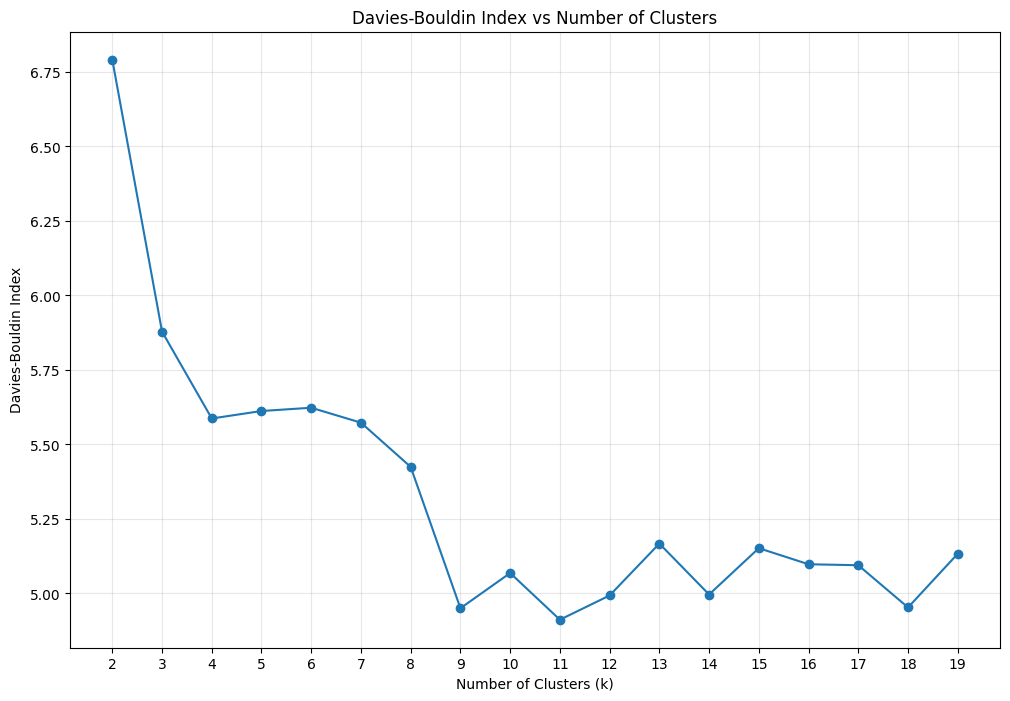


--> Optimal number of clusters: 11


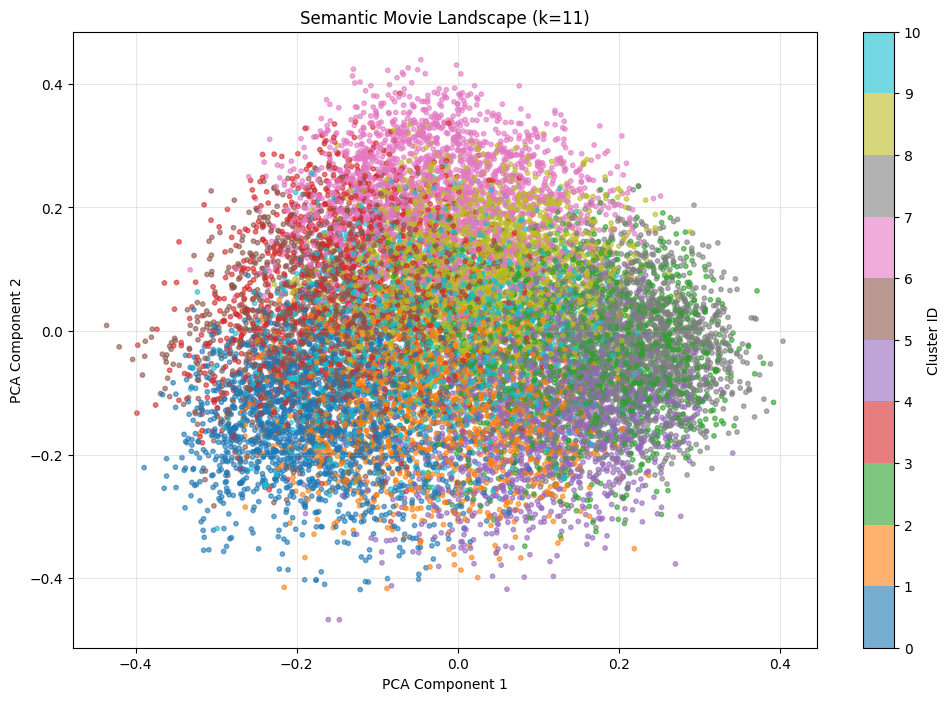

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Determine Optimal K (Davies-Bouldin Index)
print("Calculating optimization scores (DBI)...")
scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3)
    labels = kmeans.fit_predict(matrix)
    score = davies_bouldin_score(matrix, labels)
    scores.append(score)
    print(f"k={k}: {score:.4f}", end=" | ")

# Plot Davies-Bouldin Index vs K
plt.figure(figsize=(12, 8))
plt.plot(k_range, scores, marker='o')
plt.xticks(k_range)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index vs Number of Clusters")
plt.grid(alpha=0.3)
plt.show()

# Pick the best K automatically
best_k = k_range[np.argmin(scores)]
print(f"\n--> Optimal number of clusters: {best_k}")

# Run Final Clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(matrix)

# Add cluster labels to our DataFrame
df_clustered = df_vectors.with_columns(pl.Series("cluster", clusters))

# Visualize with PCA (Reduce 1536 dims -> 2 dims)
pca = PCA(n_components=2)
vis_dims = pca.fit_transform(matrix)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(vis_dims[:, 0], vis_dims[:, 1], c=clusters, cmap='tab10', s=10, alpha=0.6)

# integer ticks for the colorbar
ticks = np.arange(clusters.min(), clusters.max() + 1)
cbar = plt.colorbar(scatter, ticks=ticks)
cbar.set_label("Cluster ID")
cbar.set_ticklabels([str(int(t)) for t in ticks])

plt.title(f"Semantic Movie Landscape (k={best_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(alpha=0.3)
plt.show()

### Cluster Composition Analysis
Do these semantic clusters correspond to actual genres? 

We visualize the **"Genre DNA"** of each cluster by calculating the percentage distribution of genres within them. This helps us label the clusters (e.g., "Cluster 3 is 60% Horror").

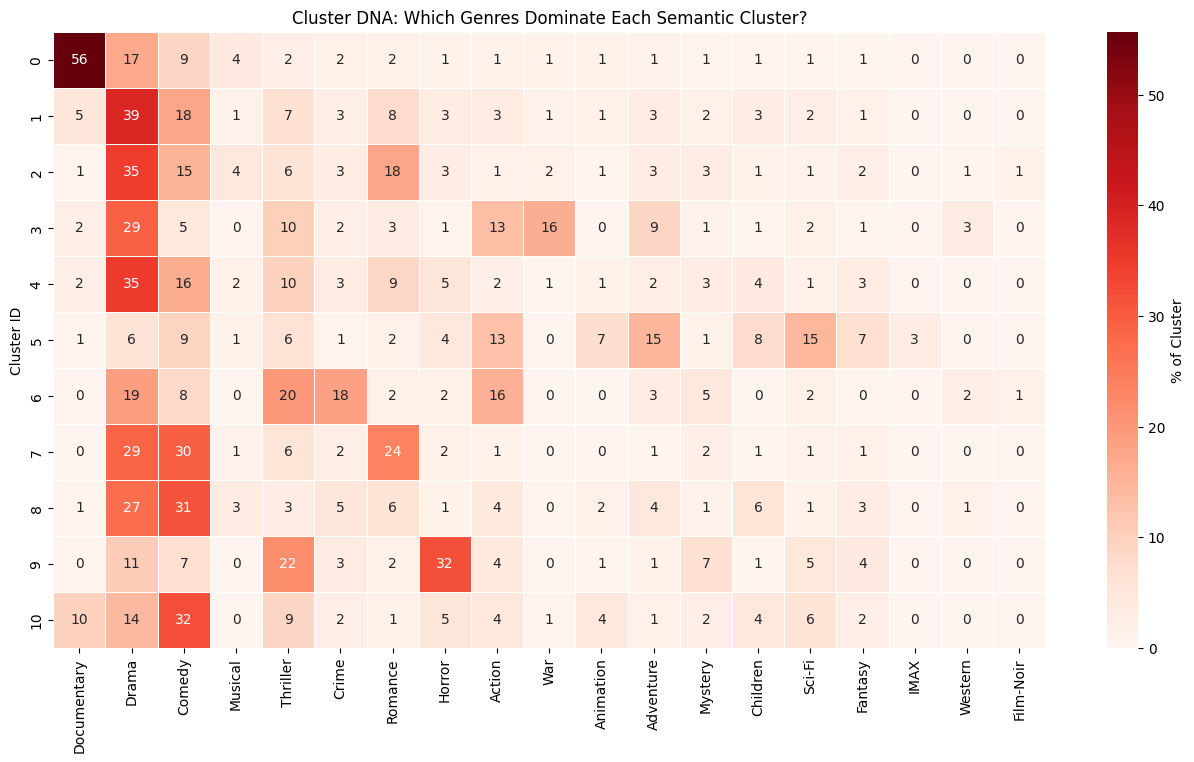

In [16]:
# Merge with Metadata to get Genres
# We need the 'lm_genre' column from our main merged dataset
df_meta = pl.read_csv("data/merged/movies_merged.csv")
df_combined = df_meta.join(df_clustered, on="rotten_tomatoes_link", how="inner")

# Process Genres (Explode movies with multiple genres)
df_exploded = (
    df_combined
    .select(["cluster", "lm_genre"]) 
    .with_columns(pl.col("lm_genre").str.split("|"))
    .explode("lm_genre")
    .filter(pl.col("lm_genre") != "(no genres listed)") 
    .filter(pl.col("lm_genre") != "Unknown")
)

# Calculate Percentages per Cluster
cluster_stats = (
    df_exploded
    .group_by(["cluster", "lm_genre"])
    .len()
    .with_columns([
        pl.col("len").sum().over("cluster").alias("cluster_total")
    ])
    .with_columns([
        (pl.col("len") / pl.col("cluster_total") * 100).alias("percentage")
    ])
    .sort(["cluster", "len"], descending=[False, True])
)

# Visualize as Heatmap
# Pivot data for plotting
pdf_pivot = (
    cluster_stats
    .pivot(on="lm_genre", index="cluster", values="percentage")
    .fill_null(0)
    .to_pandas()
    .set_index("cluster")
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    pdf_pivot, 
    annot=True, 
    fmt=".0f", 
    cmap="Reds", 
    linewidths=.5, 
    cbar_kws={'label': '% of Cluster'}
)
plt.title("Cluster DNA: Which Genres Dominate Each Semantic Cluster?")
plt.ylabel("Cluster ID")
plt.show()

### Genre Atlas: Where do different genres live?
Instead of looking at the clusters, let's look at the **Genres**. 

This heatmap answers the question: *"If I am a Horror movie, which cluster am I most likely to be in?"*
* **Dark Red Stripes** indicate a genre is "trapped" in a specific semantic region.
* **Light colors everywhere** indicate a "universal" genre (like Drama) that exists in all types of stories.

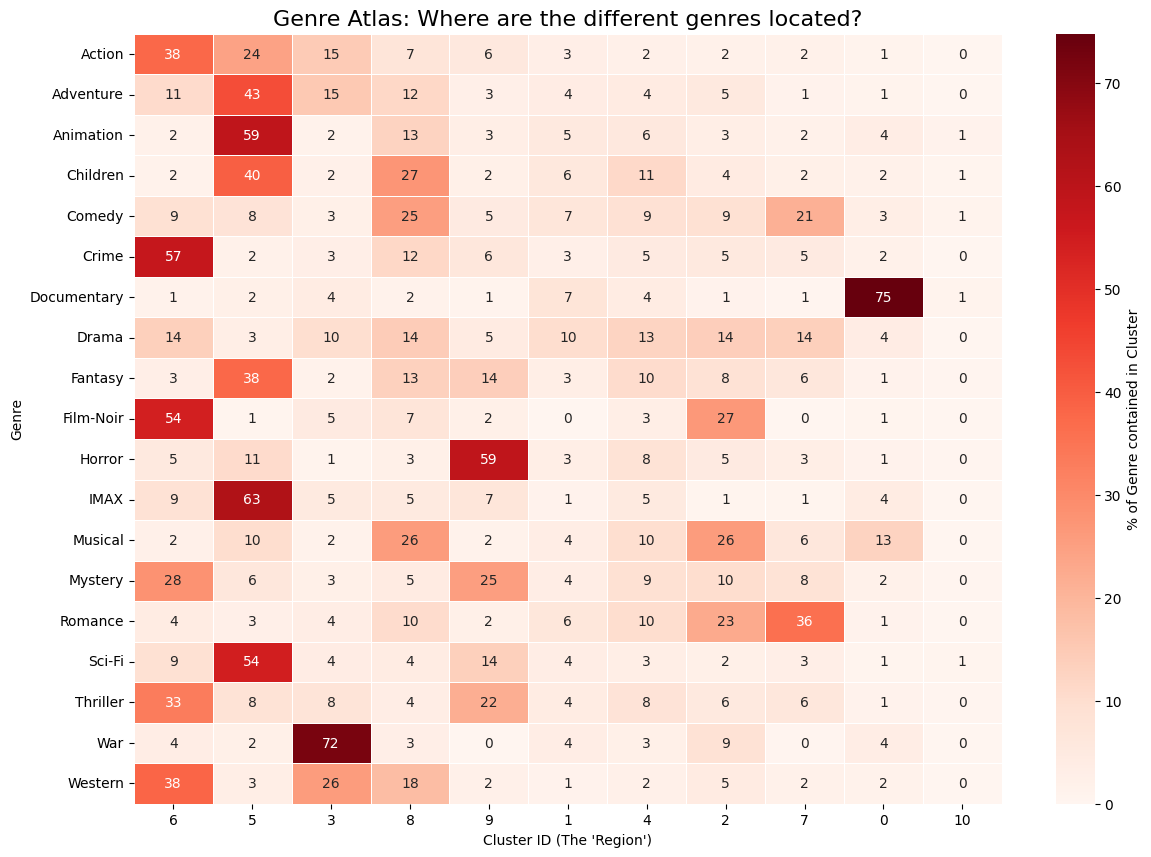

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate "Where do genres live?"
# We group by Genre first to see the distribution of that specific genre across clusters
genre_destinations = (
    df_exploded
    .group_by(["lm_genre", "cluster"])
    .len()
    .with_columns([
        pl.col("len").sum().over("lm_genre").alias("genre_total")
    ])
    .with_columns([
        (pl.col("len") / pl.col("genre_total") * 100).alias("percentage")
    ])
    .sort(["lm_genre", "percentage"], descending=[False, True])
)

# Pivot for Heatmap
# Rows = Genres, Columns = Clusters, Values = % of that Genre
pdf_genre_map = (
    genre_destinations
    .pivot(on="cluster", index="lm_genre", values="percentage")
    .fill_null(0)
    .to_pandas()
    .set_index("lm_genre")
)

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    pdf_genre_map, 
    annot=True, 
    fmt=".0f", 
    cmap="Reds", 
    linewidths=.5,
    cbar_kws={'label': '% of Genre contained in Cluster'}
)
plt.title("Genre Atlas: Where are the different genres located?", fontsize=16)
plt.xlabel("Cluster ID (The 'Region')")
plt.ylabel("Genre")
plt.show()

### Visualizing Genre Fingerprints
Finally, we visualize the spatial distribution of every genre. By plotting each genre on its own small map, we can instantly see if it forms a tight cluster (specific themes) or spreads out across the entire landscape (broad themes).


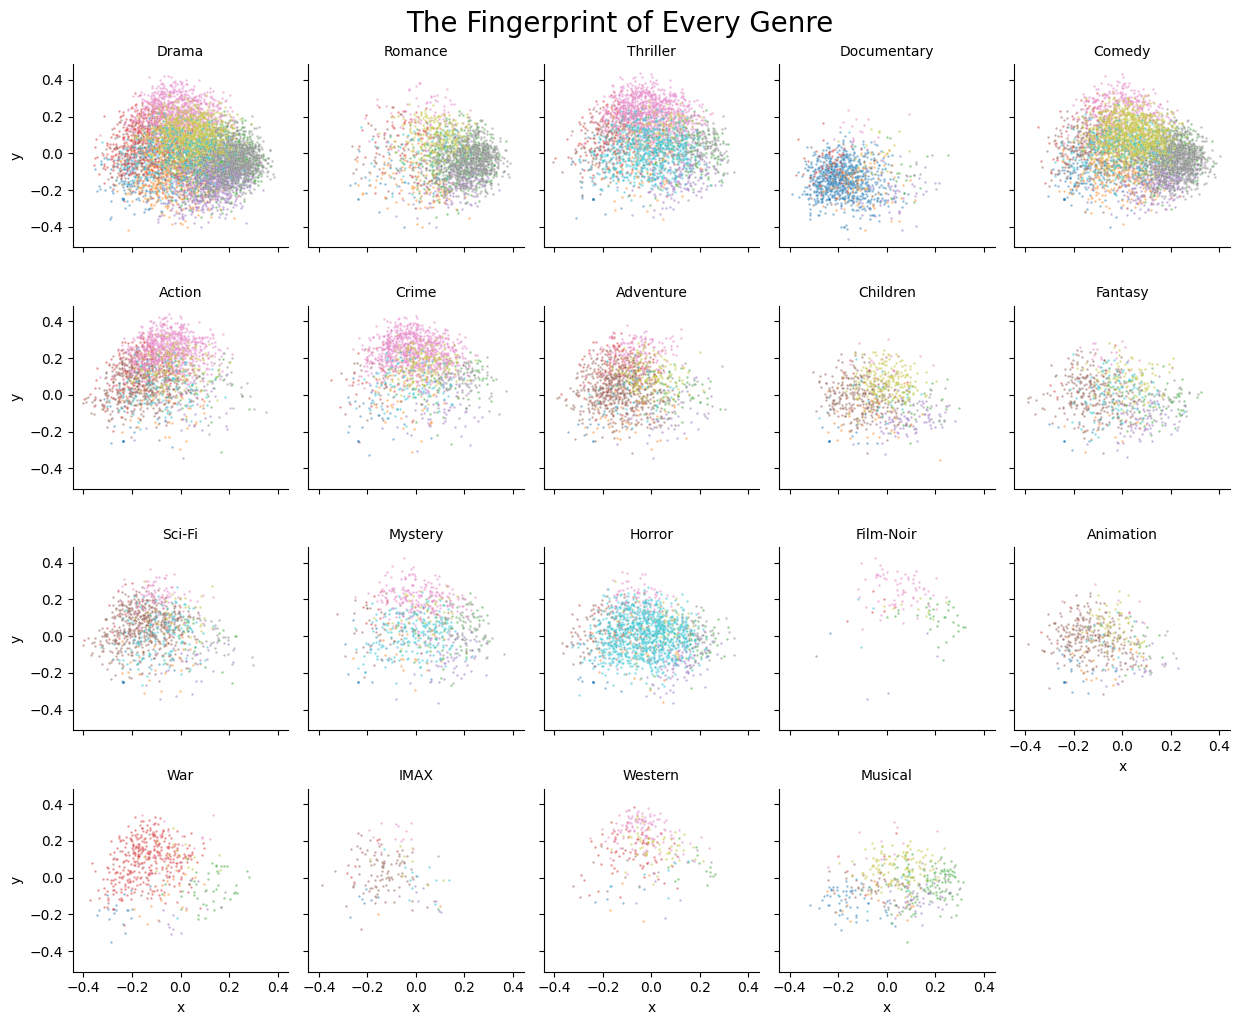

In [18]:
# Run PCA to get the 2D coordinates
pca = PCA(n_components=2)
vis_dims = pca.fit_transform(matrix)

# 2. Add 'x', 'y', and 'cluster' to the main dataframe
df_coords = df_vectors.with_columns([
    pl.Series("x", vis_dims[:, 0]),
    pl.Series("y", vis_dims[:, 1]),
    pl.Series("cluster", clusters)
])

# Merge with Metadata (to get Genres)
df_combined = df_meta.join(df_coords, on="rotten_tomatoes_link", how="inner")

# Explode Genres (CRITICAL: Select 'x' and 'y' this time!)
df_exploded = (
    df_combined
    .select(["x", "y", "cluster", "lm_genre"])
    .with_columns(pl.col("lm_genre").str.split("|"))
    .explode("lm_genre")
    .filter(pl.col("lm_genre") != "(no genres listed)") 
    .filter(pl.col("lm_genre") != "Unknown")
)

# Prepare data for plotting
pdf_plot = df_exploded.to_pandas()

# Create Facet Grid
g = sns.FacetGrid(
    pdf_plot, 
    col="lm_genre", 
    col_wrap=5,       # 5 plots per row
    hue="cluster",    # Color points by their semantic cluster
    palette="tab10", 
    height=2.5, 
    aspect=1
)

g.map(sns.scatterplot, "x", "y", s=3, alpha=0.5)
g.set_titles("{col_name}") 
g.fig.suptitle("The Fingerprint of Every Genre", y=1.02, fontsize=20)

plt.show()

### Semantic Search: Finding Movies by "Vibe"
Embeddings allow us to perform math on concepts. We can take a list of movies that share a specific "vibe" (e.g., "Epic Blockbusters" or "Indie Dramas"), average their vectors, and find other movies that are mathematically similar.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Define Theme Lists (Curated examples)
list_1 = ["The Matrix", "Alien", "Blade Runner", "The Dark Knight", "Gladiator", "Toy Story", "Shrek", "The Lion King", "Titanic", "Solo: A Star Wars Story"]
list_2 = ["The Notebook", "Pride and Prejudice", "La La Land", "Crazy Rich Asians", "Pretty Woman", "Notting Hill", "Love Actually", "The Fault in Our Stars", "A Star Is Born", "Me Before You"]
list_3 = ["The Conjuring", "The Exorcist", "Insidious", "Get Out", "Paranormal Activity", "It Follows", "The Witch", "Hereditary", "A Quiet Place", "Saw"]
list_4 = ["Pulp Fiction", "Fight Club", "The Godfather", "Taxi Driver", "There Will Be Blood", "Moonlight", "Lady Bird", "Eternal Sunshine of the Spotless Mind", "Her", "Whiplash"]
list_5 = ["Frozen", "Moana", "Finding Nemo", "Despicable Me", "Paddington 2", "How to Train Your Dragon", "Zootopia", "Inside Out", "Coco", "The Incredibles"]

themes = ["Epic/Blockbuster", "Romantic / Love Stories", "Horror / Thriller", "Film Buff / Indie Drama", "Kids / Family"]
all_lists = [list_1, list_2, list_3, list_4, list_5]

# Prepare for Search
# We need to look up vectors by title
all_vectors = np.stack(df_vectors["embedding"].to_numpy())

# Run Semantic Search
for i, history in enumerate(all_lists):
    theme_name = themes[i]
    print(f"\n--- {theme_name} ---")
    
    # Get vectors for the input movies
    history_df = df_vectors.filter(pl.col("title").is_in(history))
    if history_df.height == 0: continue

    # Create a "Theme Vector" (Average of inputs)
    user_vector = np.stack(history_df["embedding"].to_numpy()).mean(axis=0).reshape(1, -1)

    # Find closest matches
    scores = cosine_similarity(user_vector, all_vectors).flatten()
    sorted_idx = scores.argsort()[::-1]
    
    seen = set(history)
    count = 0
    for idx in sorted_idx:
        title = df_vectors["title"][int(idx)]
        if title not in seen:
            print(f"{scores[idx]:.4f} | {title}")
            count += 1
            if count >= 5: break


--- Epic/Blockbuster ---
0.6101 | Blade Runner: The Final Cut
0.5959 | Star Wars: The Force Awakens
0.5882 | Star Wars: Episode VI - Return of the Jedi
0.5852 | Regarding Henry
0.5807 | In the Name of the King: A Dungeon Siege Tale

--- Romantic / Love Stories ---
0.6744 | Playing by Heart
0.6694 | The Dish & the Spoon
0.6691 | Love the Hard Way
0.6657 | A Four Letter Word
0.6609 | Two Lovers

--- Horror / Thriller ---
0.7155 | Lovely Molly
0.7031 | Marrowbone
0.7027 | Lights Out
0.6952 | Paranormal Activity 4
0.6943 | The Conjuring 2

--- Film Buff / Indie Drama ---
0.6714 | The Salton Sea
0.6586 | Light Sleeper
0.6564 | Sin City
0.6519 | 21 Grams
0.6477 | The Informers

--- Kids / Family ---
0.6280 | The Florida Project
0.6280 | Nim's Island
0.6096 | Ice Age: Continental Drift
0.6069 | Hoodwinked Too! Hood vs. Evil
0.6040 | The Little Mermaid


### Validation:
To prove that these embeddings capture actual user taste, we perform a controlled experiment.

**The Experiment:**
1.  We take critics with 20+ reviews.
2.  We split their history: 80% for training (building the profile) and 20% for testing.
3.  We calculate the Spearman Rank Correlation between our predicted similarity scores and their actual ratings.
4.  Goal: A positive correlation means our AI correctly guessed which movies the critic would like.

Validating on 345 critics (Random Split)...
Global Average Spearman Correlation: -0.0655


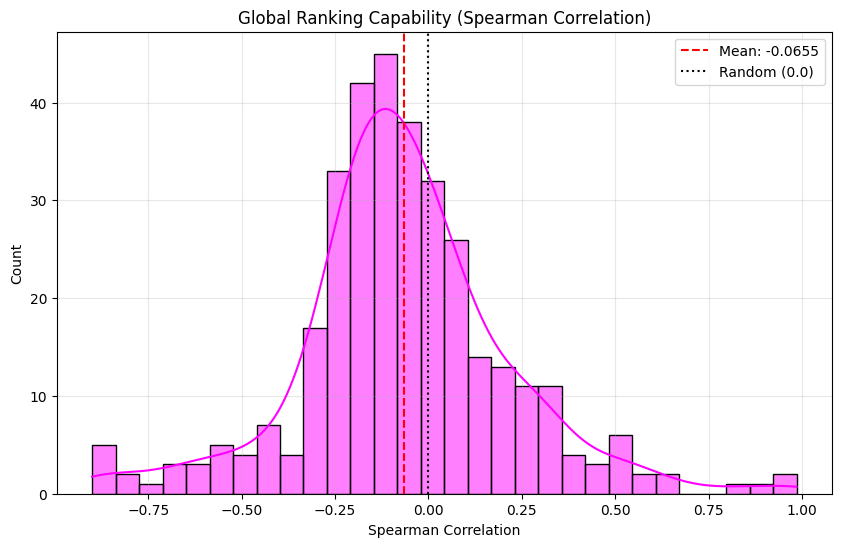

In [20]:
from scipy.stats import spearmanr

# Load Reviews and Merge with Embeddings
# We need to link the numeric review score with the semantic vector of the movie
df_reviews = pl.read_csv("data/clean/rotten_tomatoes_critic_reviews_clean.csv")

df_data = (
    df_reviews
    .filter(pl.col("review_score_numeric").is_not_null())
    .join(df_vectors, on="rotten_tomatoes_link", how="inner")
)

def validate_spearman(min_reviews=20, split_ratio=0.8, seed=42, threshold=3.0):
    # Select Critics with enough history (>= 20 reviews)
    valid_critics = (
        df_data.group_by("critic_name")
        .len()
        .filter(pl.col("len") >= min_reviews)
        .select("critic_name")
        .to_series()
        .to_list()
    )
    
    print(f"Validating on {len(valid_critics)} critics (Random Split)...")
    correlations = []
    
    for critic in valid_critics:
        # Get history and shuffle randomly
        history = df_data.filter(pl.col("critic_name") == critic)
        history = history.sample(fraction=1.0, shuffle=True, seed=seed)
        
        # Create Train (80%) and Test (20%) sets
        n = len(history)
        cut = int(n * split_ratio)
        train, test = history.head(cut), history.tail(n - cut)
        
        # We need at least 5 test movies to calculate a meaningful correlation
        if len(test) < 5: continue
            
        # Build Profile from Train set 
        # (Only using "Positive" movies >= 3.0 to calculate the user's taste vector)
        good_train = train.filter(pl.col("review_score_numeric") >= threshold)
        
        # If they hated everything in the train set, we can't build a profile
        if len(good_train) == 0: continue
            
        # User Vector = Mean of Liked Movies
        user_vector = np.stack(good_train["embedding"].to_numpy()).mean(axis=0).reshape(1, -1)
        
        # Predict on Test set
        # We predict how much they will like the Test movies based on semantic similarity
        test_vecs = np.stack(test["embedding"].to_numpy())
        predicted_sims = cosine_similarity(user_vector, test_vecs).flatten()
        actual_scores = test["review_score_numeric"].to_numpy()
        
        # Calculate Spearman Correlation
        # Do our semantic predictions rank the movies in the same order as the actual ratings?
        if np.std(actual_scores) > 0:
            corr, _ = spearmanr(predicted_sims, actual_scores)
            if not np.isnan(corr): 
                correlations.append(corr)

    # Report Results
    if correlations:
        avg_corr = np.mean(correlations)
        print(f"Global Average Spearman Correlation: {avg_corr:.4f}")
        
        # Visualize distribution
        plt.figure(figsize=(10, 6))
        sns.histplot(correlations, bins=30, kde=True, color='magenta', edgecolor='black')
        plt.axvline(avg_corr, color='red', linestyle='--', label=f'Mean: {avg_corr:.4f}')
        plt.axvline(0.0, color='black', linestyle=':', label='Random (0.0)')
        plt.title('Global Ranking Capability (Spearman Correlation)')
        plt.xlabel('Spearman Correlation')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# Run Validation
validate_spearman()

## 6.3 Graph analysis

The graph anlysis is demonstrated in the `analyze_actor_network.py` script. You can run it on a subset of the data for quick testing:

```bash
task run-graph-analysis-subset
```

However for the full analysis, run:

```bash
task analyze-actor-network
```

This does take a while to run on the full dataset.

In [10]:
# Run graph analysis on a subset of data for quick demo
# This analyzes movie networks based on shared actors using community detection methods
# The subset is 5000 nodes
!task run-graph-analysis-subset

# !task analyze-actor-network

2025-12-07 11:16:49 | INFO | __main__:main:1050 - 🚀 Starting actor network analysis...
2025-12-07 11:16:49 | INFO | __main__:load_actor_film_data:53 - 📊 Loading actor-film data...
2025-12-07 11:16:49 | INFO | __main__:load_actor_film_data:103 -    Subset to 5000 films: 22927 actor-film relationships
2025-12-07 11:16:49 | INFO | __main__:main:1054 -    Loaded 22927 actor-film relationships
2025-12-07 11:16:49 | INFO | __main__:build_movie_coactor_graph:118 - 🔨 Building movie co-actor graph...
2025-12-07 11:16:49 | INFO | __main__:build_movie_coactor_graph:128 -    Found 7003 unique actors
2025-12-07 11:16:49 | INFO | __main__:build_movie_coactor_graph:147 -    Found 52595 movie pairs with shared actors
2025-12-07 11:16:49 | INFO | __main__:build_movie_coactor_graph:154 - ✅ Graph constructed: 4838 nodes, 52595 edges
2025-12-07 11:16:49 | INFO | __main__:apply_girvan_newman:175 - 🔍 Applying Girvan-Newman method (target: 10 communities)...
2025-12-07 11:16:49 | INFO | __main__:apply_girvan

task: [run-graph-analysis-subset] uv run python src/02807_project/analyze_actor_network.py --subset-size 5000



📁 Generated analysis files:

🖼️  Visualization plots (7 files):
   communities_fast_spectral_clustering.png


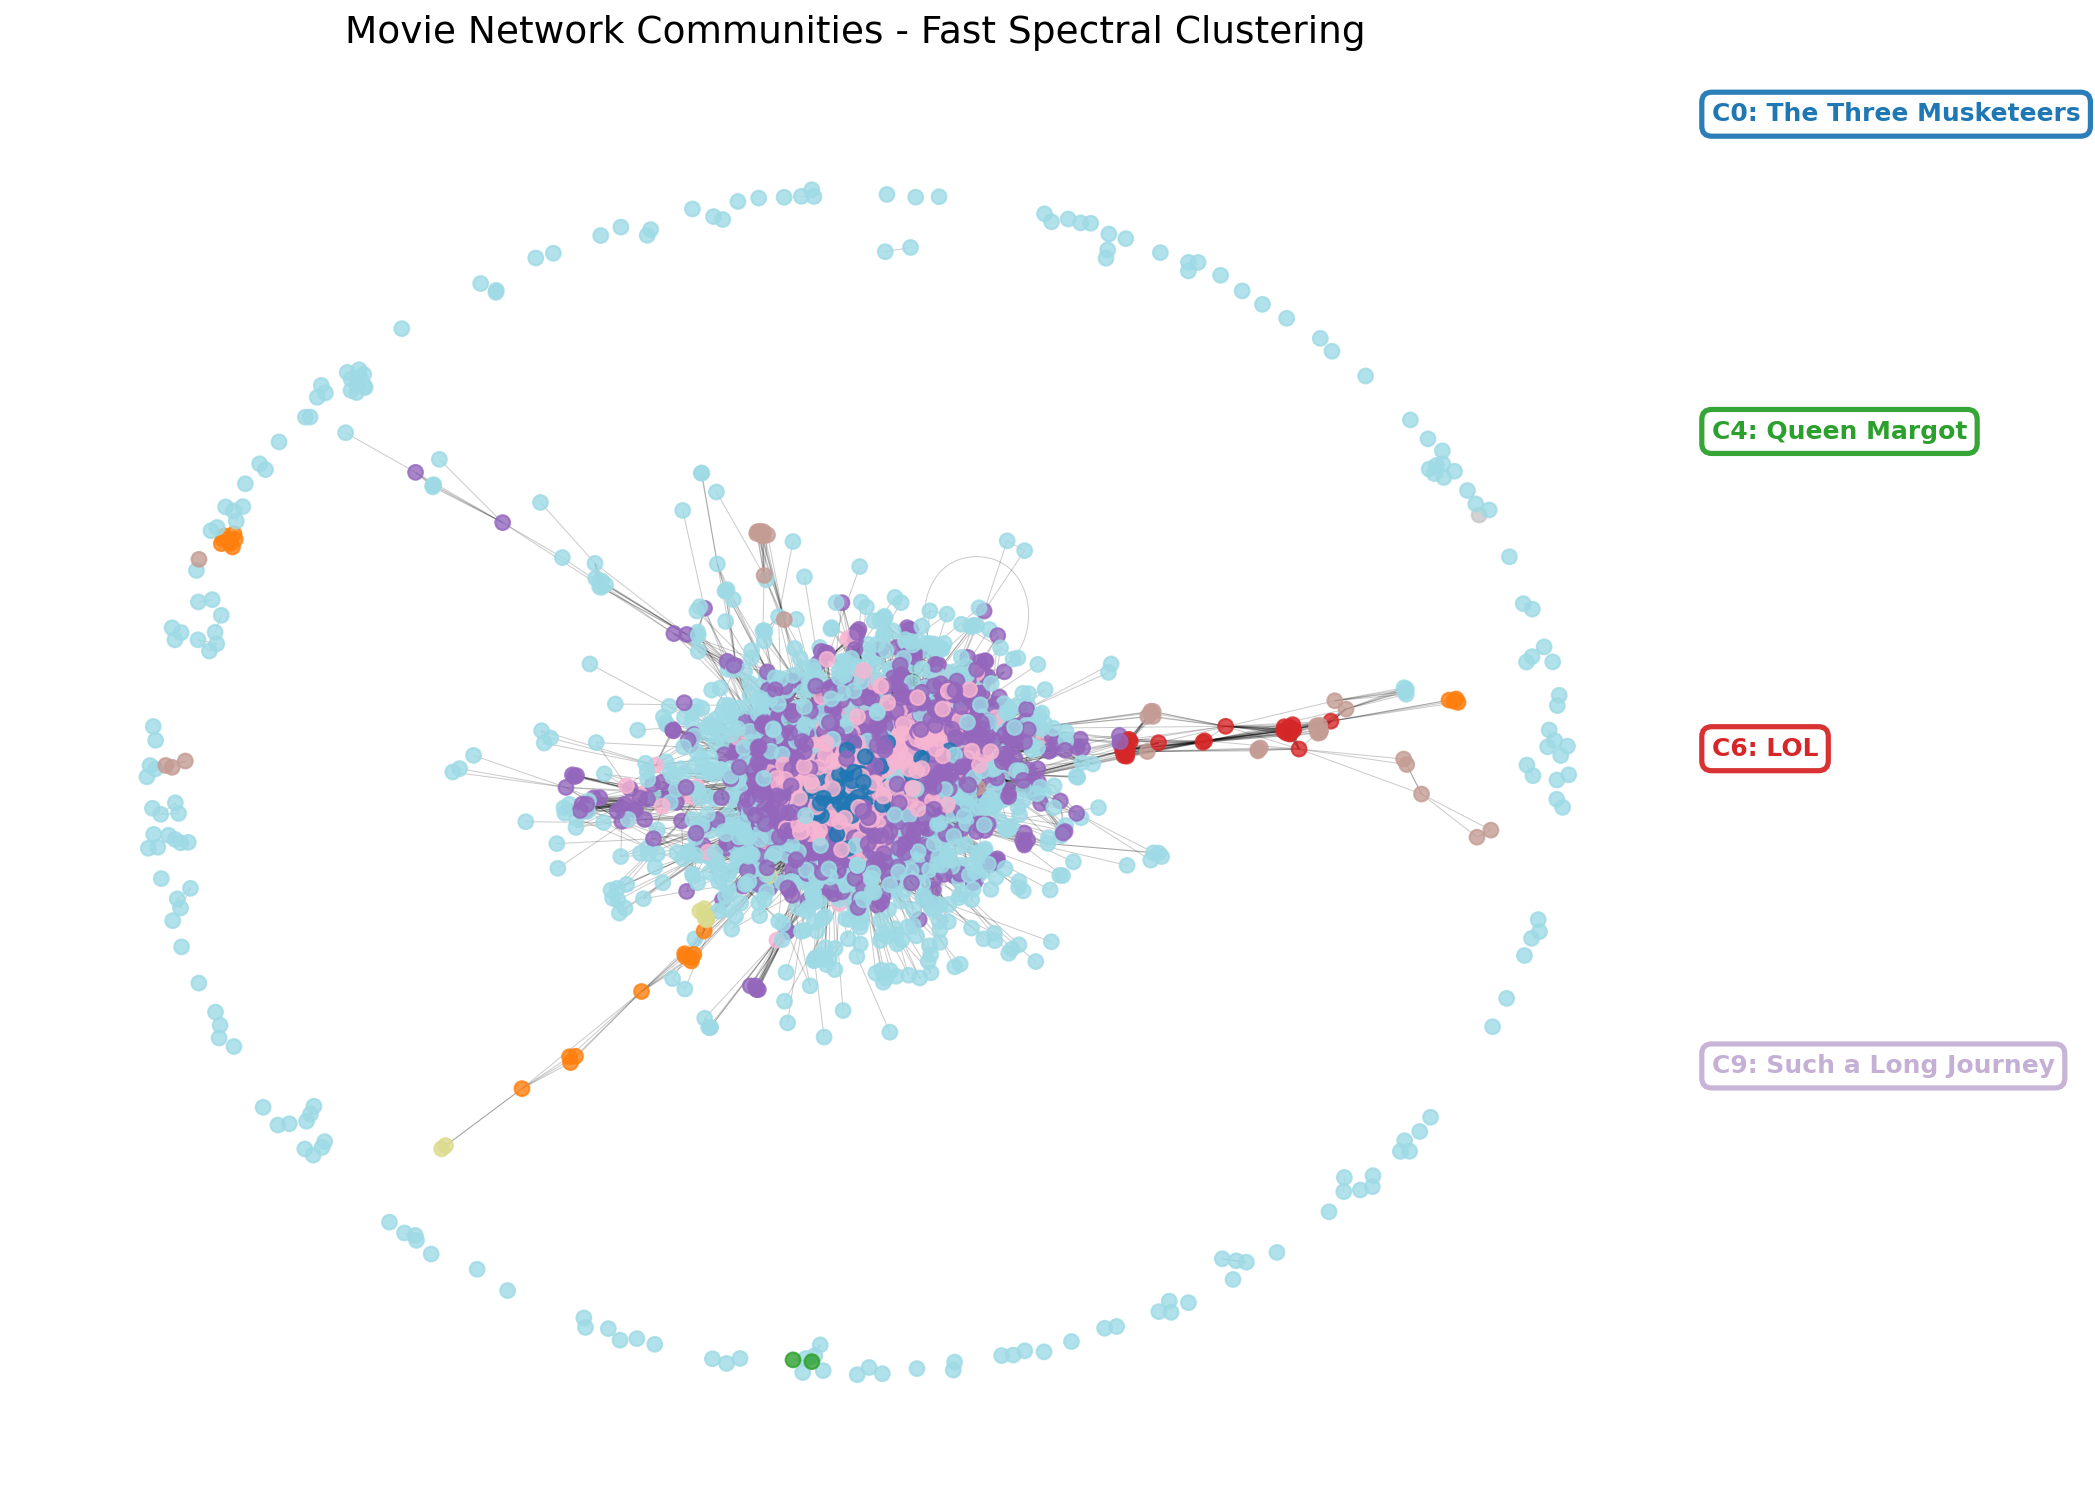

   communities_girvan-newman.png


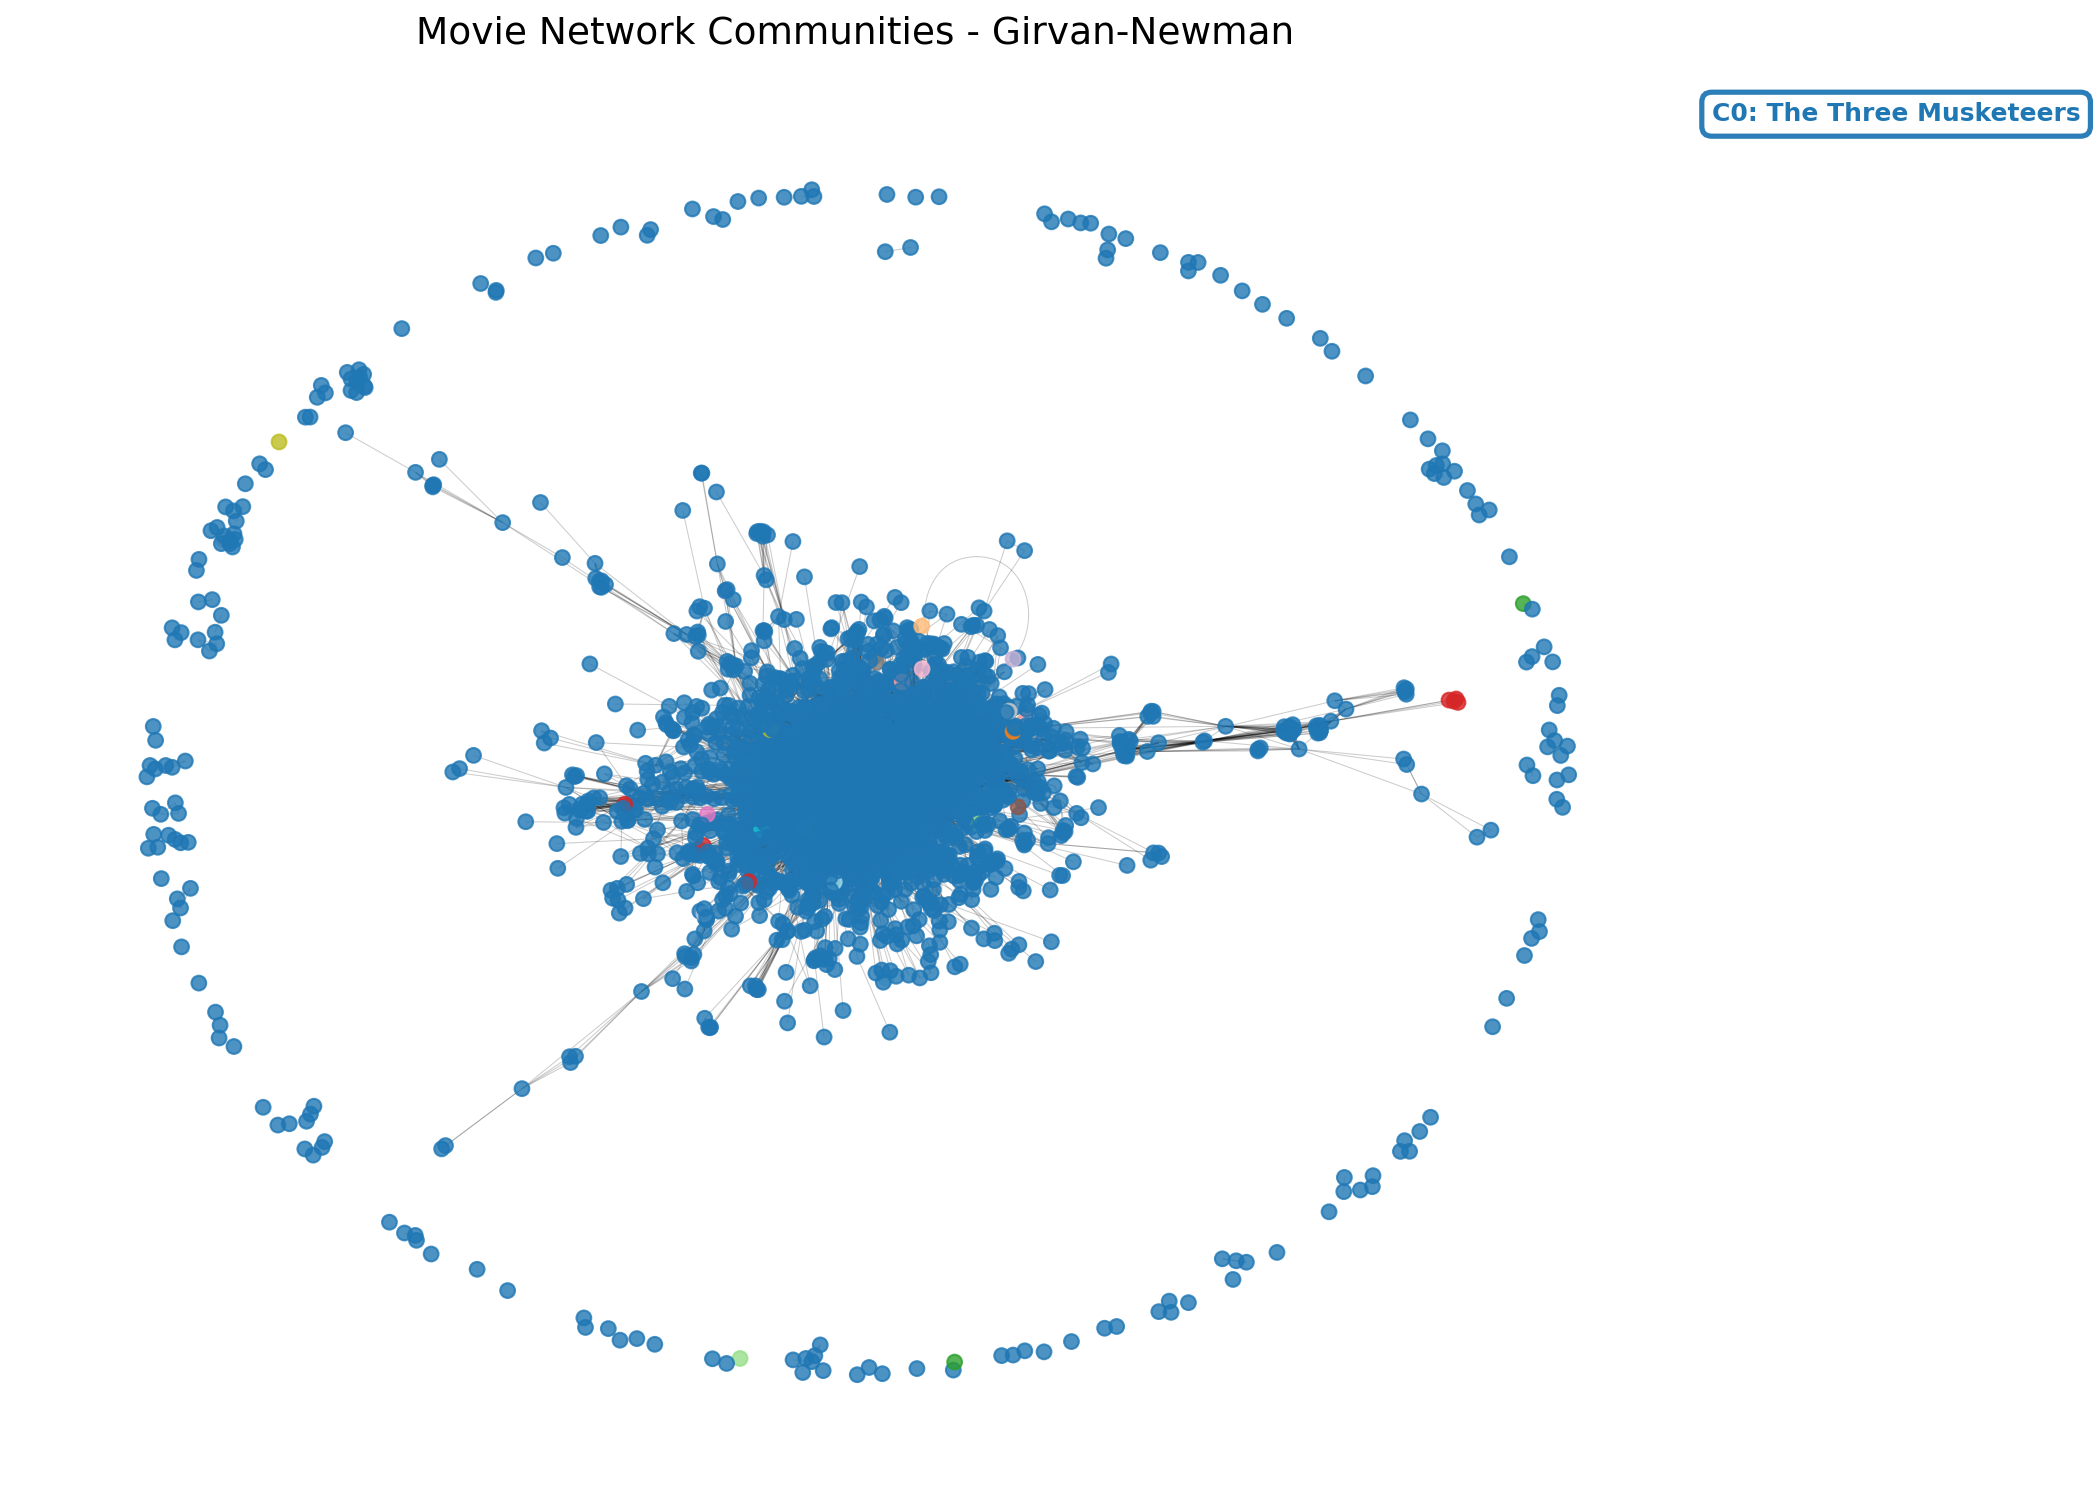

   communities_louvain.png


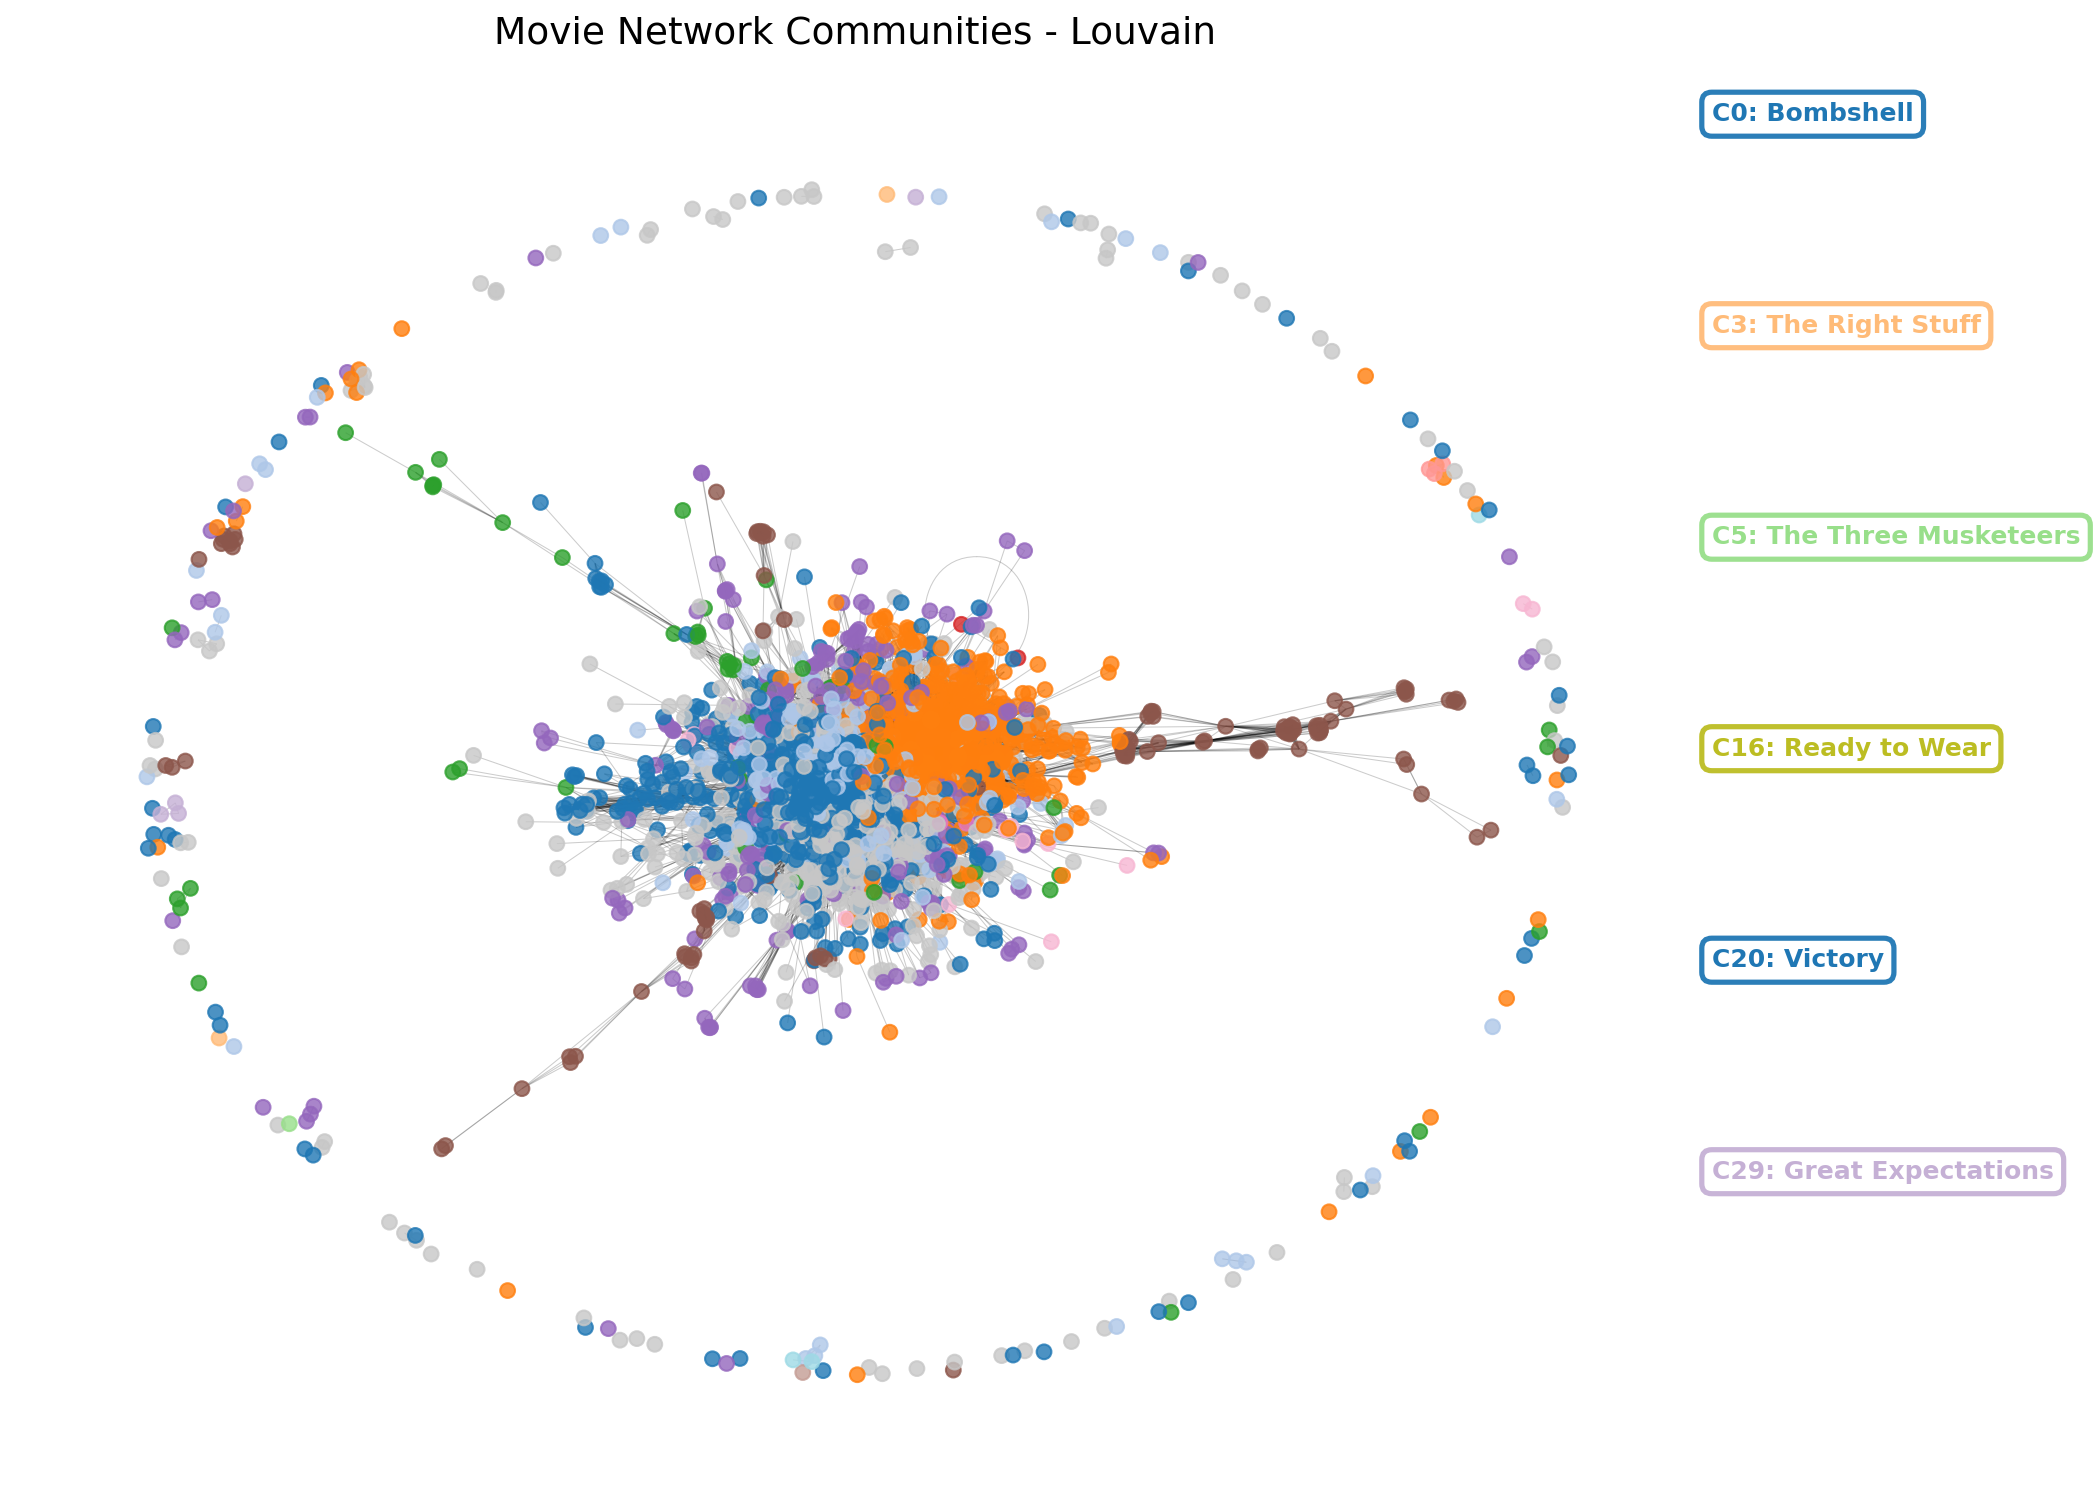

   network_graph.png


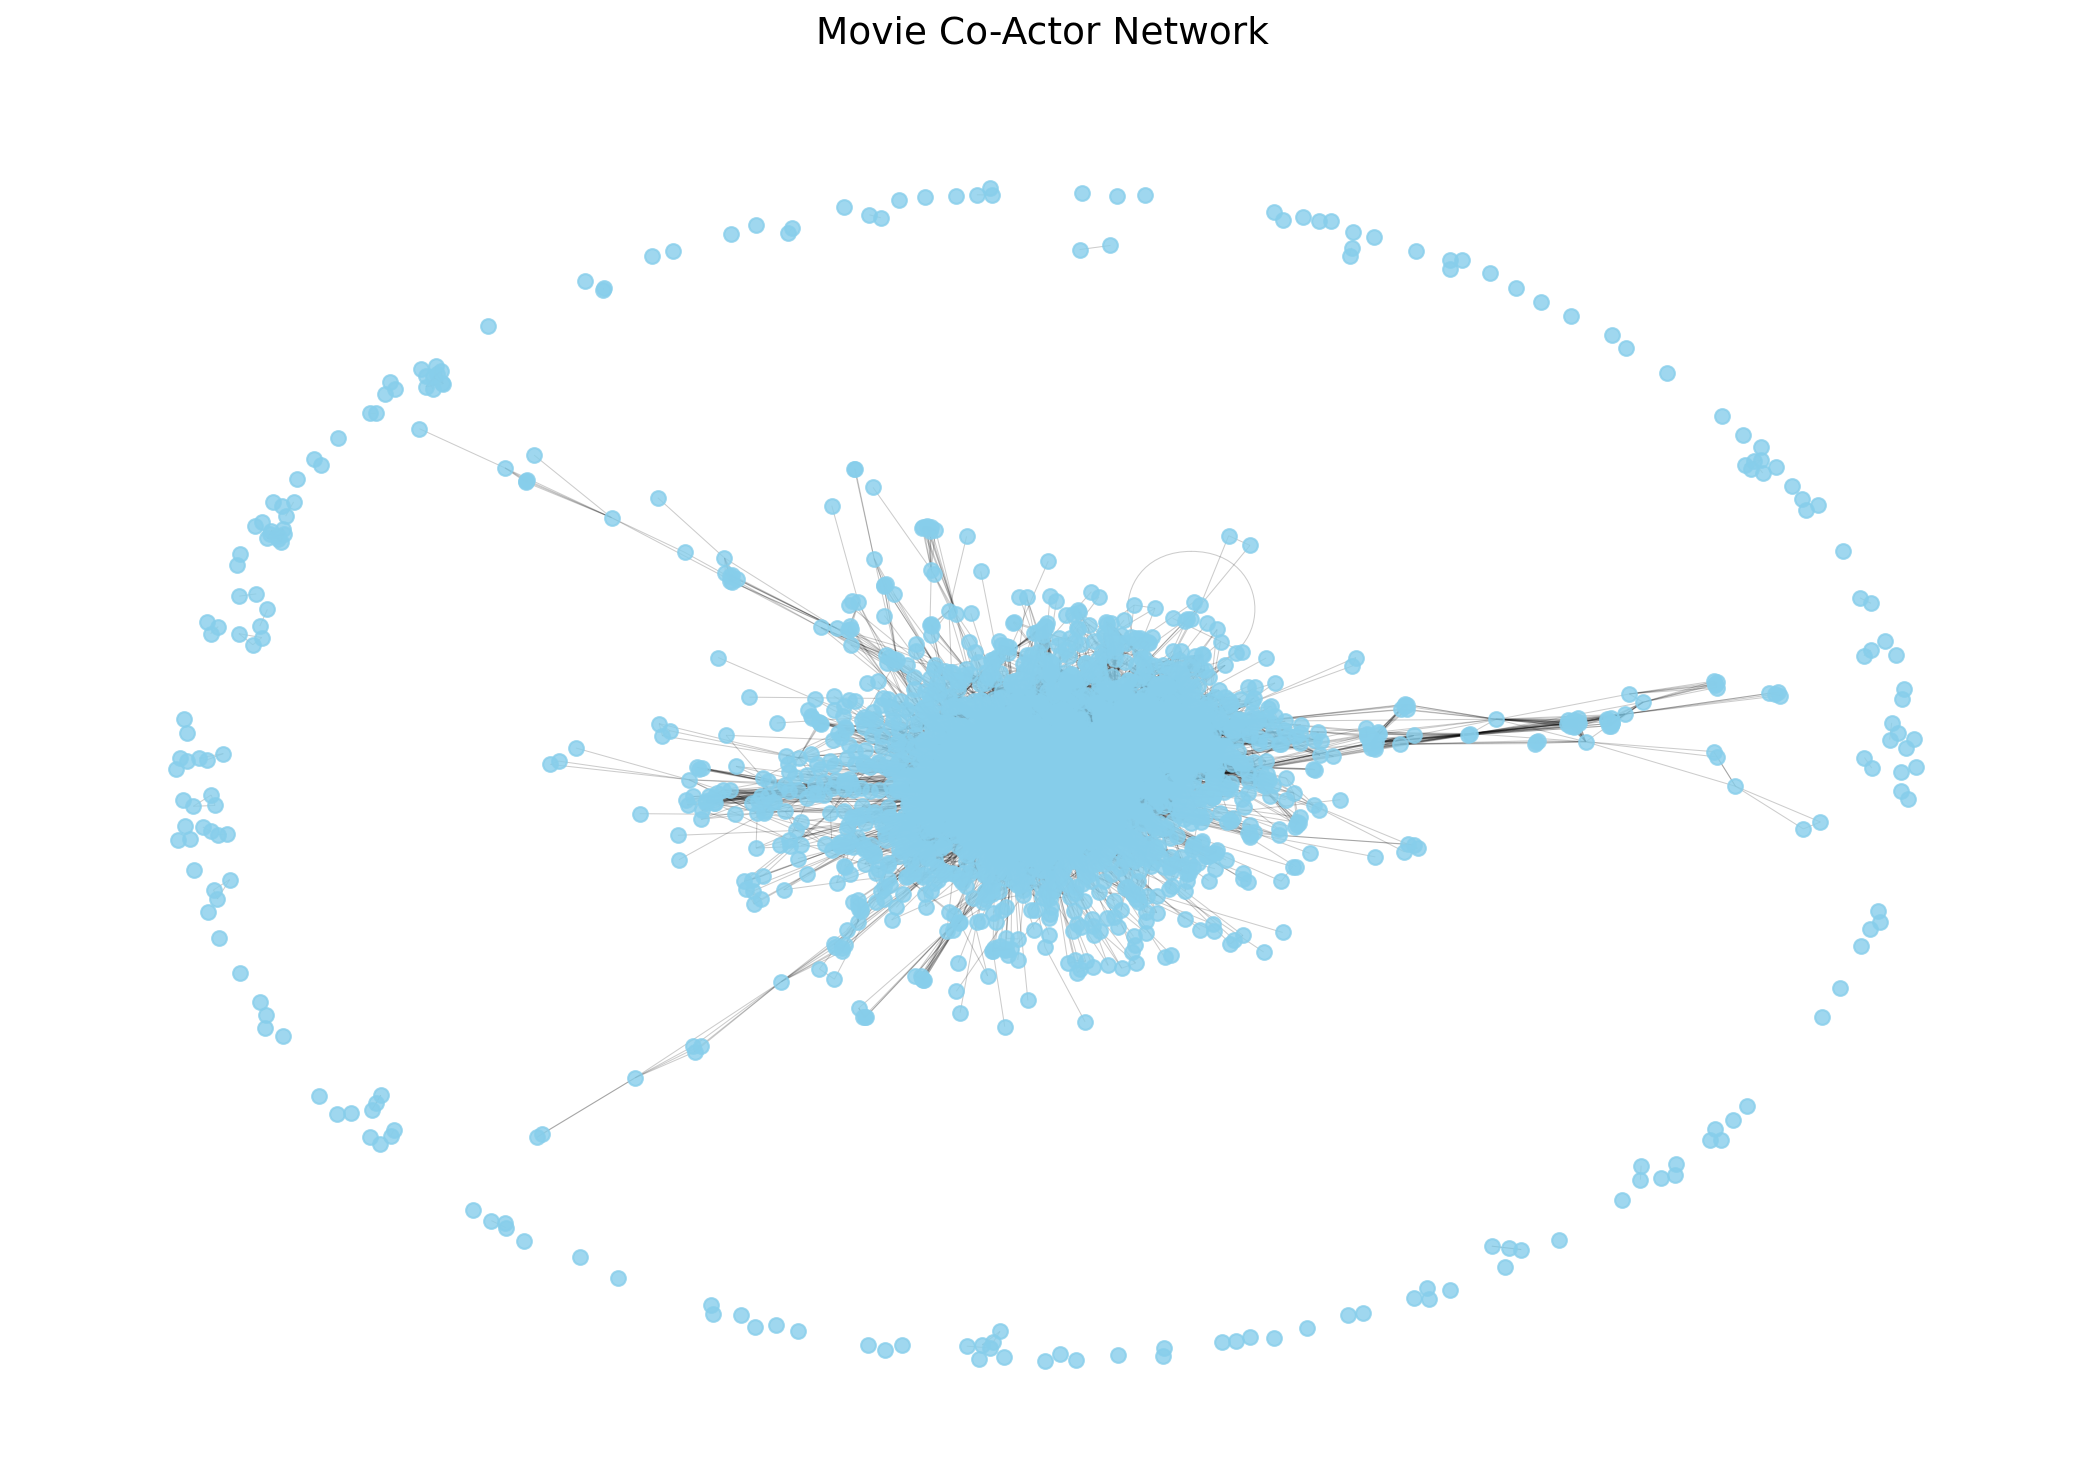

   top_movies_fast_spectral_clustering.png


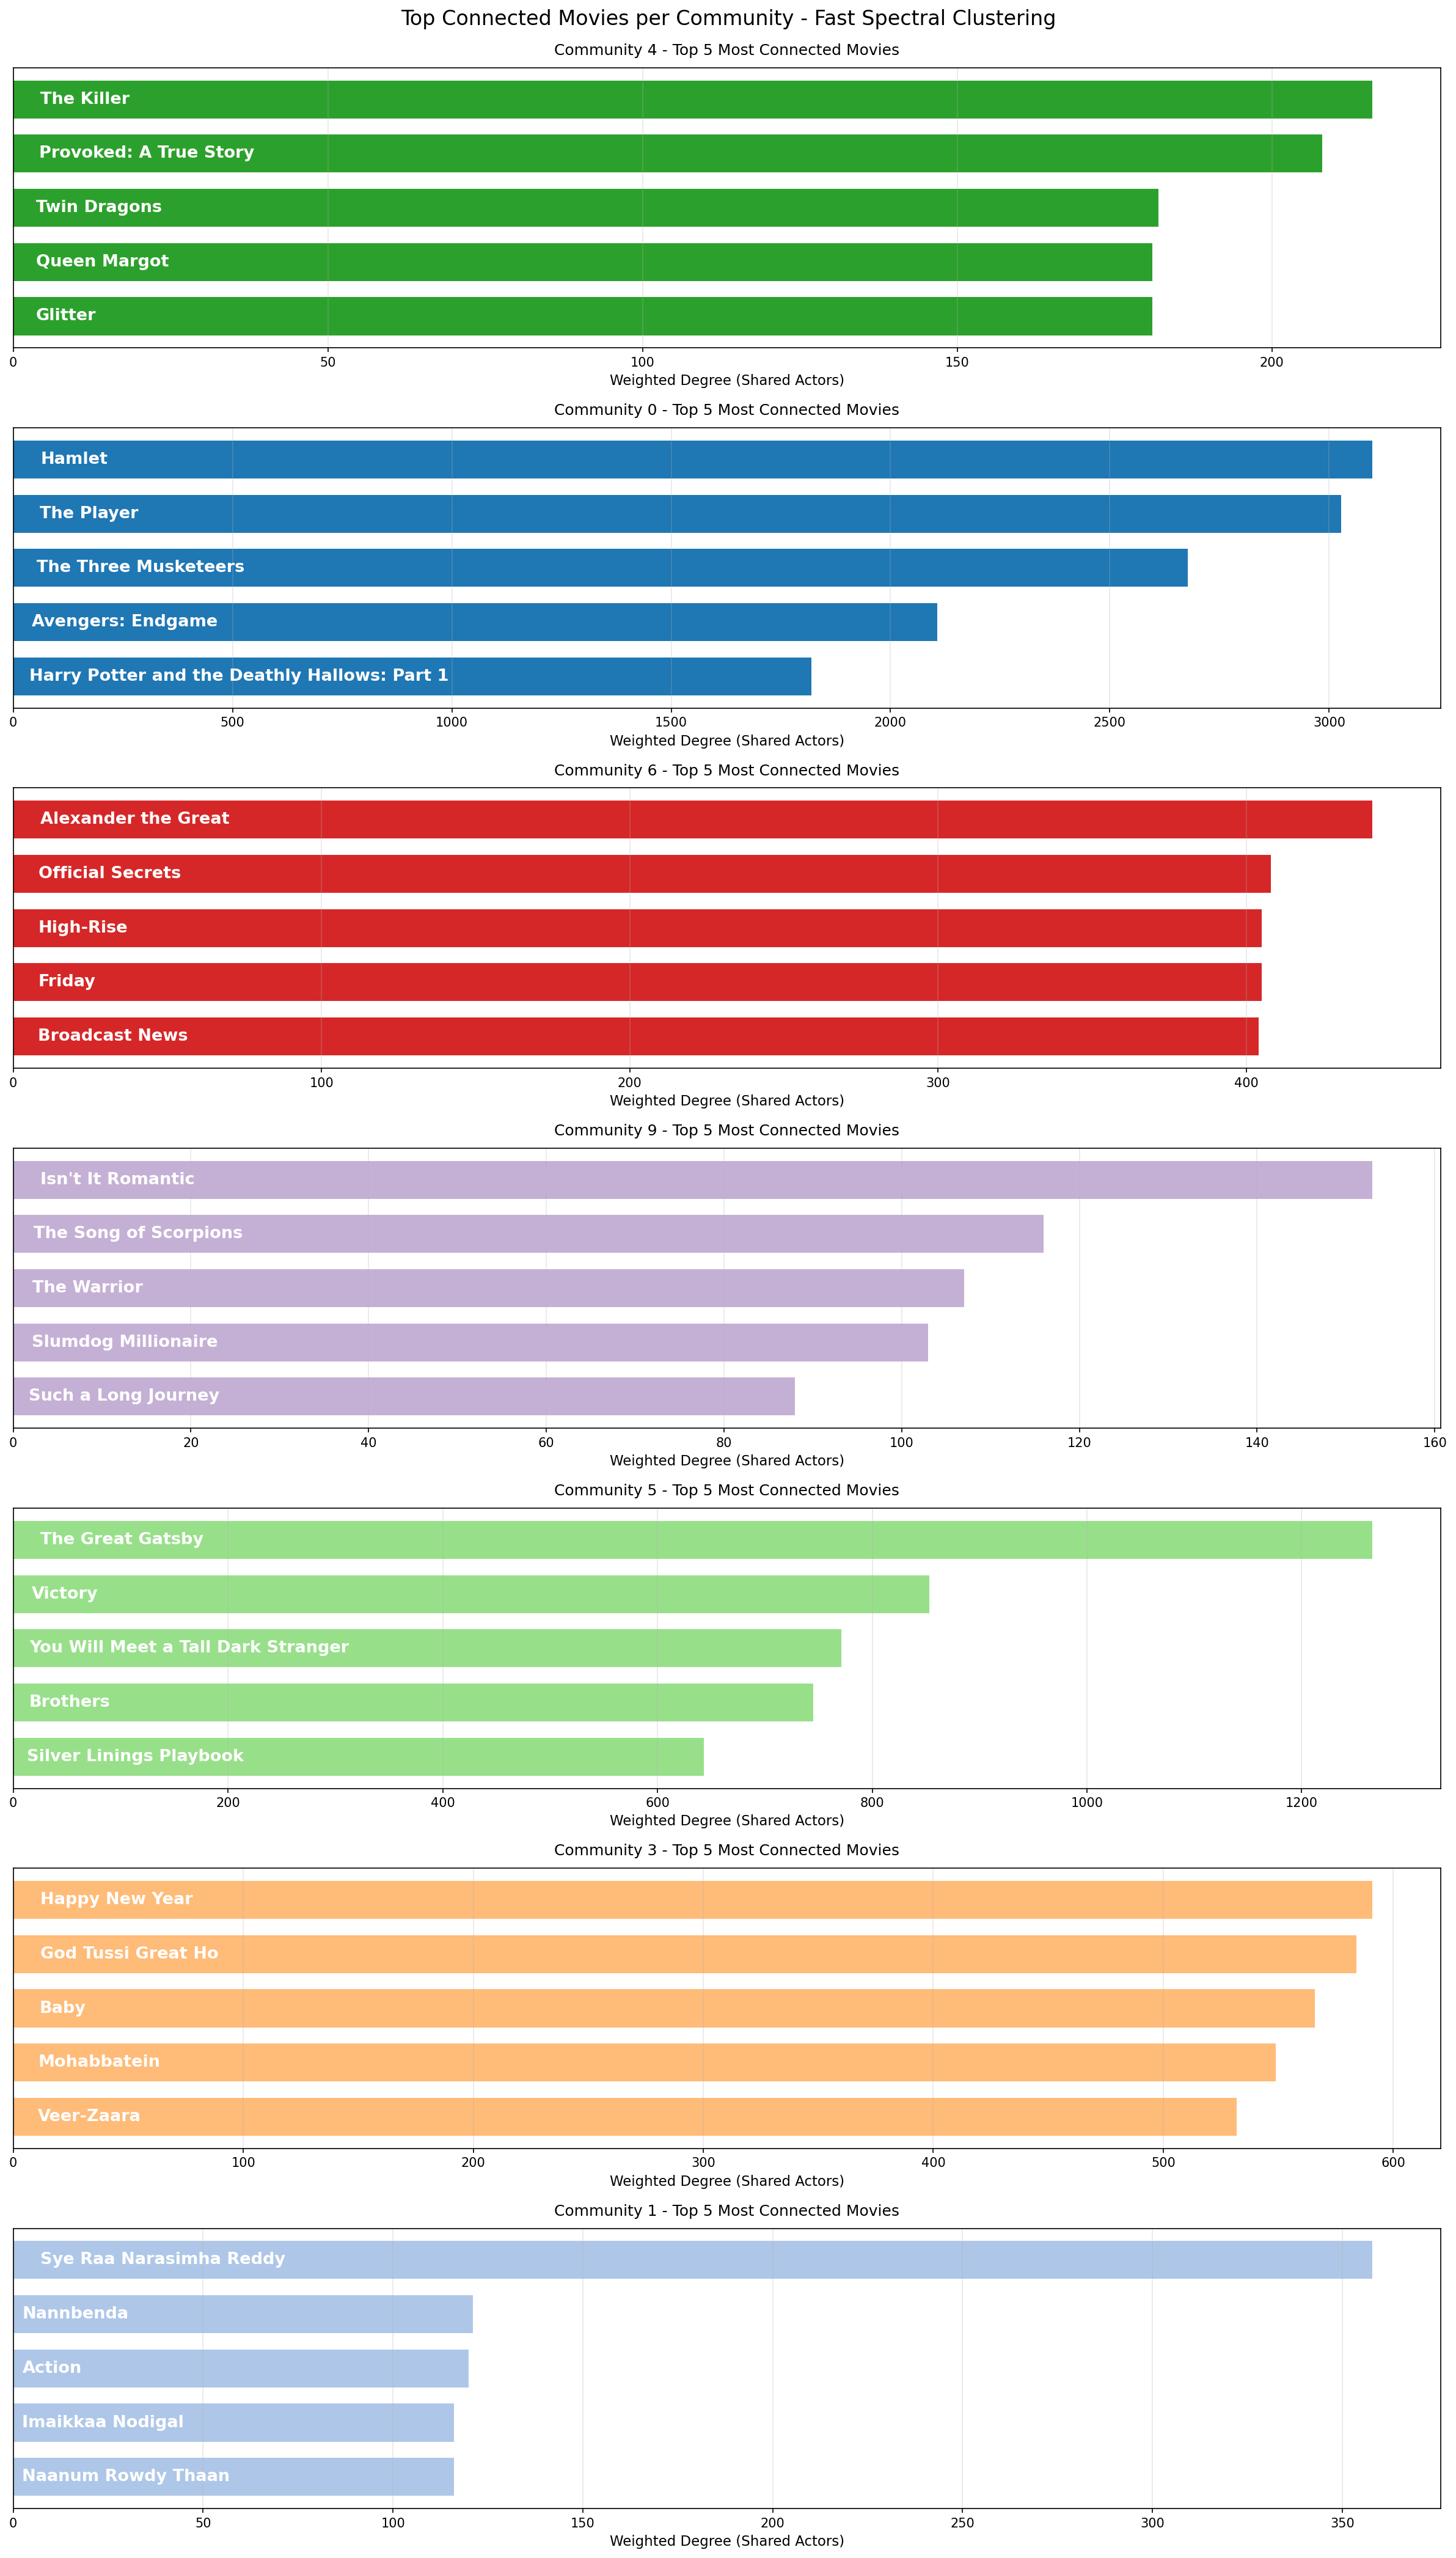

   top_movies_girvan-newman.png


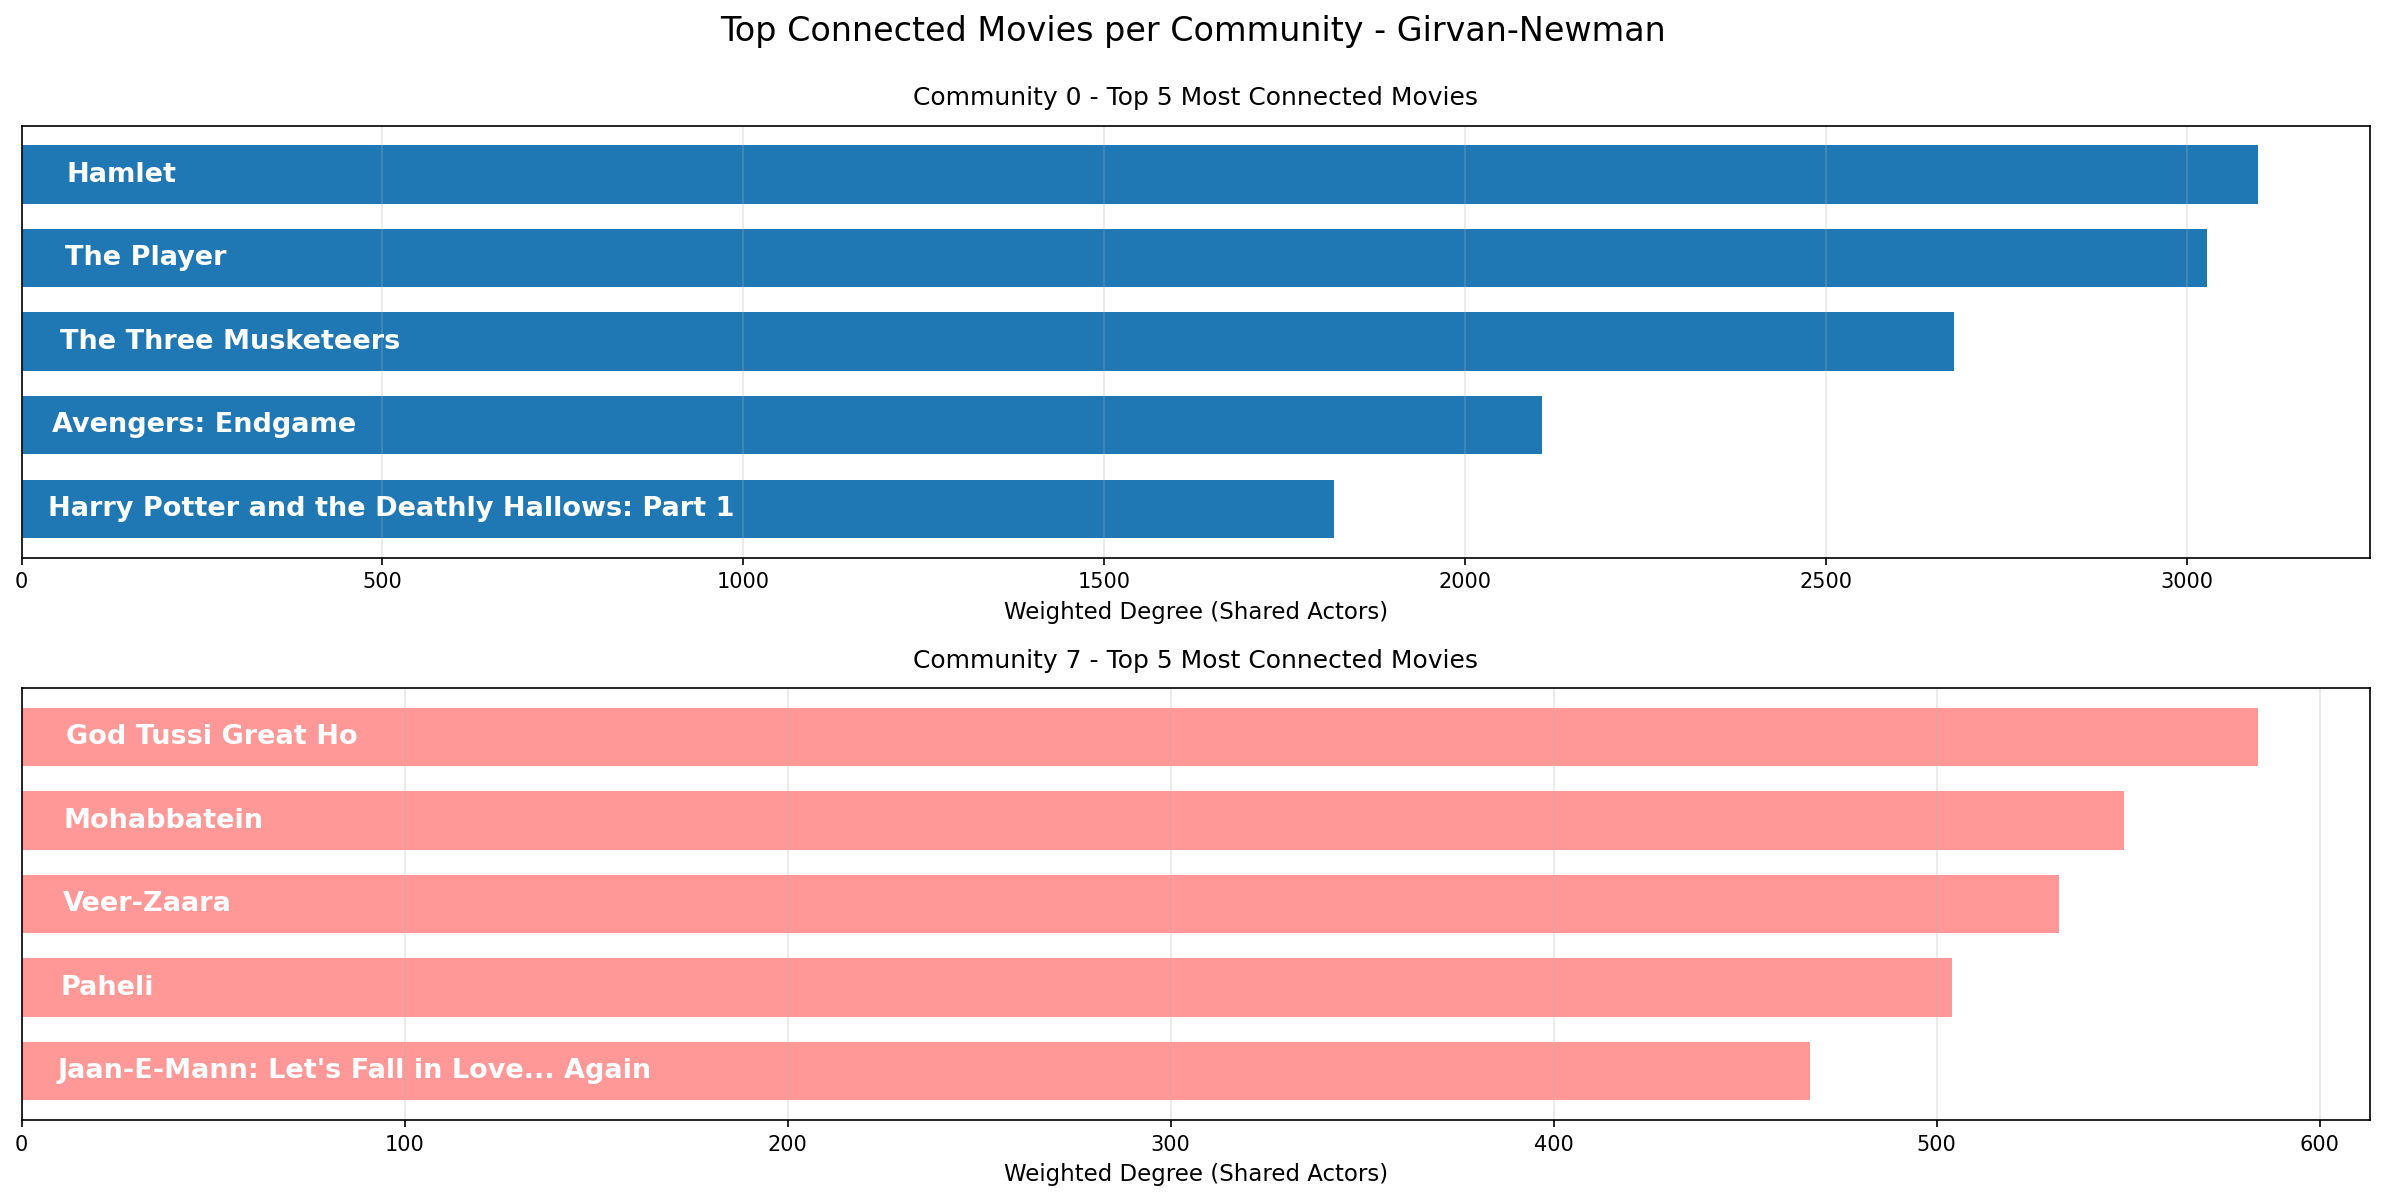

   top_movies_louvain.png


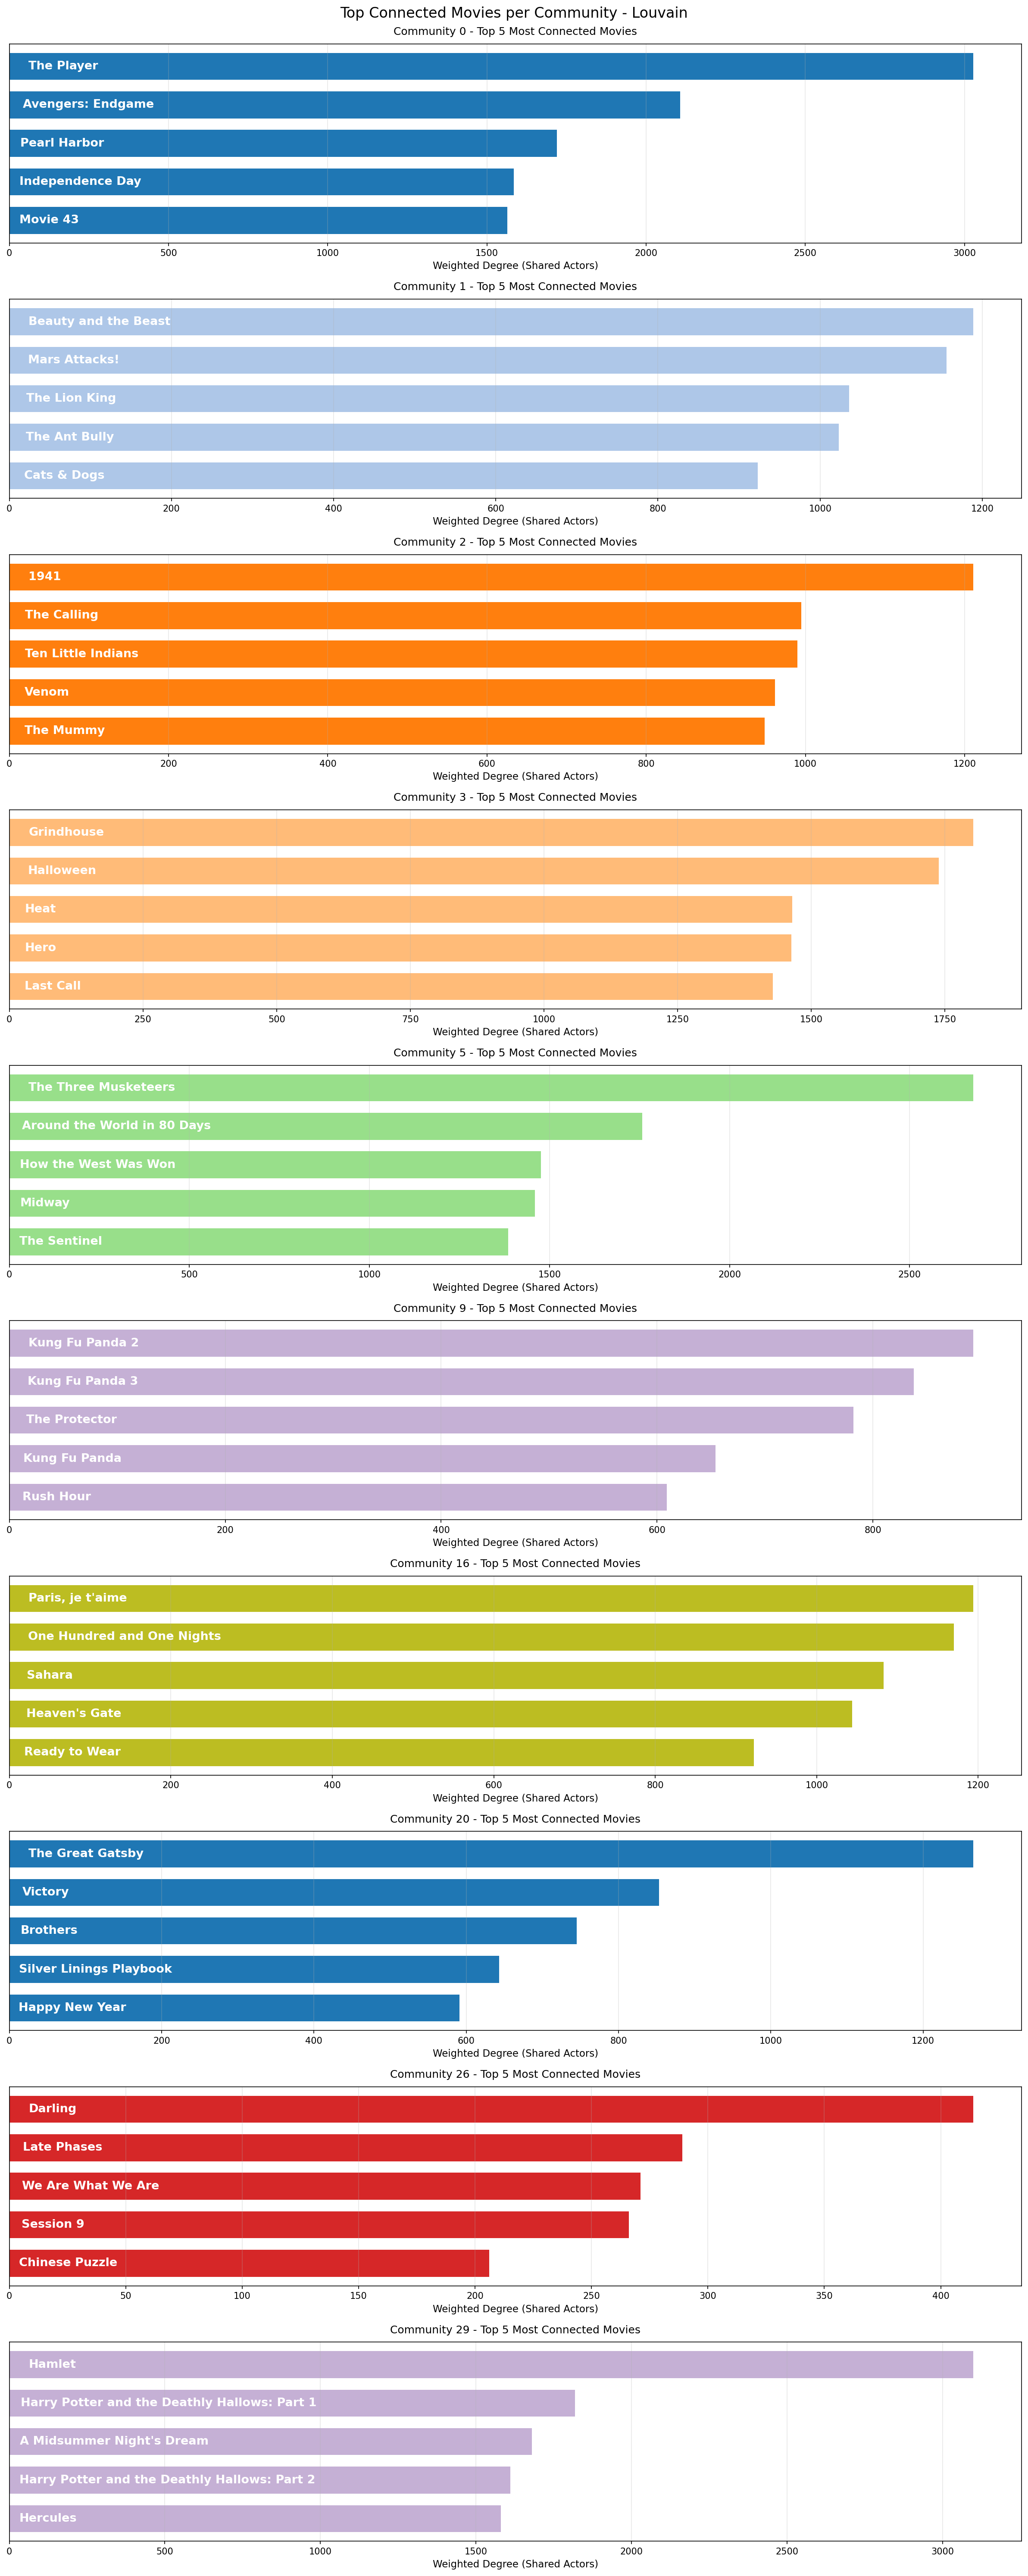


📊 Analysis data (4 files):
   community_assignments.json
   community_statistics.json


### Community Detection Results

**Girvan-Newman**: 210 communities, Modularity: 0.0323, Largest community: 39824 movies

**Louvain**: 43 communities, Modularity: 0.4079, Largest community: 13145 movies

**Fast Spectral Clustering**: 76 communities, Modularity: 0.0836, Largest community: 13365 movies

...

### Null Model Comparison

**Girvan-Newman**: Null model: 0.0000 ± 0.0000 (10 models)

**Louvain**: Null model: -0.0000 ± 0.0002 (10 models)

**Fast Spectral Clustering**: Null model: 0.0000 ± 0.0004 (10 models)

   top_movies_per_community.json

🔗 Graph files (1 files):
   movie_coactor_graph.gexf (4857330 bytes)


In [ ]:
# Show the generated plots and files
from pathlib import Path
from IPython.display import Image, display, Markdown
import json

analysis_dir = Path("data/analysis")

if analysis_dir.exists():
    print("📁 Generated analysis files:")

    # Show visualization images
    image_files = list(analysis_dir.glob("*.png"))
    if image_files:
        image_files = [img_file for img_file in image_files if img_file.name != "similarity_heatmap.png"]
        print(f"\n🖼️  Visualization plots ({len(image_files)} files):")
        for img_file in sorted(image_files):
            print(f"   {img_file.name}")
            display(Image(filename=str(img_file), width=800))

    # Show JSON data files
    json_files = list(analysis_dir.glob("*.json"))
    if json_files:
        print(f"\n📊 Analysis data ({len(json_files)} files):")
        for json_file in sorted(json_files):
            print(f"   {json_file.name}")

            # Display community statistics in a nice format
            if "statistics" in json_file.name:
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)

                    if "community_statistics" in json_file.name:
                        display(Markdown("### Community Detection Results"))
                        for stat in data:
                            display(Markdown(f"**{stat['method']}**: {stat['num_communities']} communities, "
                                           f"Modularity: {stat['modularity']:.4f}, "
                                           f"Largest community: {stat['largest_community']} movies"))
                    elif "null_model_statistics" in json_file.name:
                        display(Markdown("### Null Model Comparison"))
                        for stat in data:
                            display(Markdown(f"**{stat['method']}**: "
                                           f"Null model: {stat['mean_modularity']:.4f} ± {stat['std_modularity']:.4f} "
                                           f"({stat['num_models']} models)"))
                except Exception as e:
                    print(f"   Could not display {json_file.name}: {e}")

    # Show graph file
    graph_files = list(analysis_dir.glob("*.gexf"))
    if graph_files:
        print(f"\n🔗 Graph files ({len(graph_files)} files):")
        for g_file in graph_files:
            print(f"   {g_file.name} ({g_file.stat().st_size} bytes)")

else:
    print("❌ Analysis directory not found. Run the graph analysis first.")

## 6.4 Collaborative filtering

The collaborative filtering analysis is demonstrated in the `visualize_similarities.py` script.

```bash
task run-visualize-similarities
```
(The above takes about 8-9 minutes to run).

If you want to run the full analysis with test and train, use:

```bash
task run-collaborative-filtering
```

In [11]:
!task run-visualize-similarities -- --n-movies 5 --min-common-users 200

# Runs collaborative filterings
# !task run-collaborative-filtering

2025-12-07 11:18:29 | INFO | __main__:main:182 - Loading ratings data...
2025-12-07 11:18:33 | INFO | collaborative_filtering:load_ratings_data:50 - Filtering movies with rating >= 0.0: removed 0.0% of ratings
2025-12-07 11:18:54 | INFO | collaborative_filtering:load_ratings_data:72 - Loaded 24899017 ratings from 162541 users for 54888 movies
2025-12-07 11:18:54 | INFO | __main__:main:186 - Computing item similarities...
2025-12-07 11:18:56 | INFO | collaborative_filtering:compute_item_similarity:156 - Computing similarity for 54888 movies
2025-12-07 11:18:56 | INFO | collaborative_filtering:compute_item_similarity:158 - Constructing sparse user-item matrix...
2025-12-07 11:19:18 | INFO | collaborative_filtering:compute_item_similarity:186 - Sparse matrix shape: (162541, 54888), stored elements: 24899017
2025-12-07 11:19:18 | INFO | collaborative_filtering:compute_item_similarity:188 - Computing item-item similarity using sparse matrix operations...
2025-12-07 11:22:08 | INFO | collabo

task: [run-visualize-similarities] uv run python src/02807_project/visualize_similarities.py --n-movies 5 --min-common-users 200




🖼️  Visualization plots (1 files):
   similarity_heatmap.png


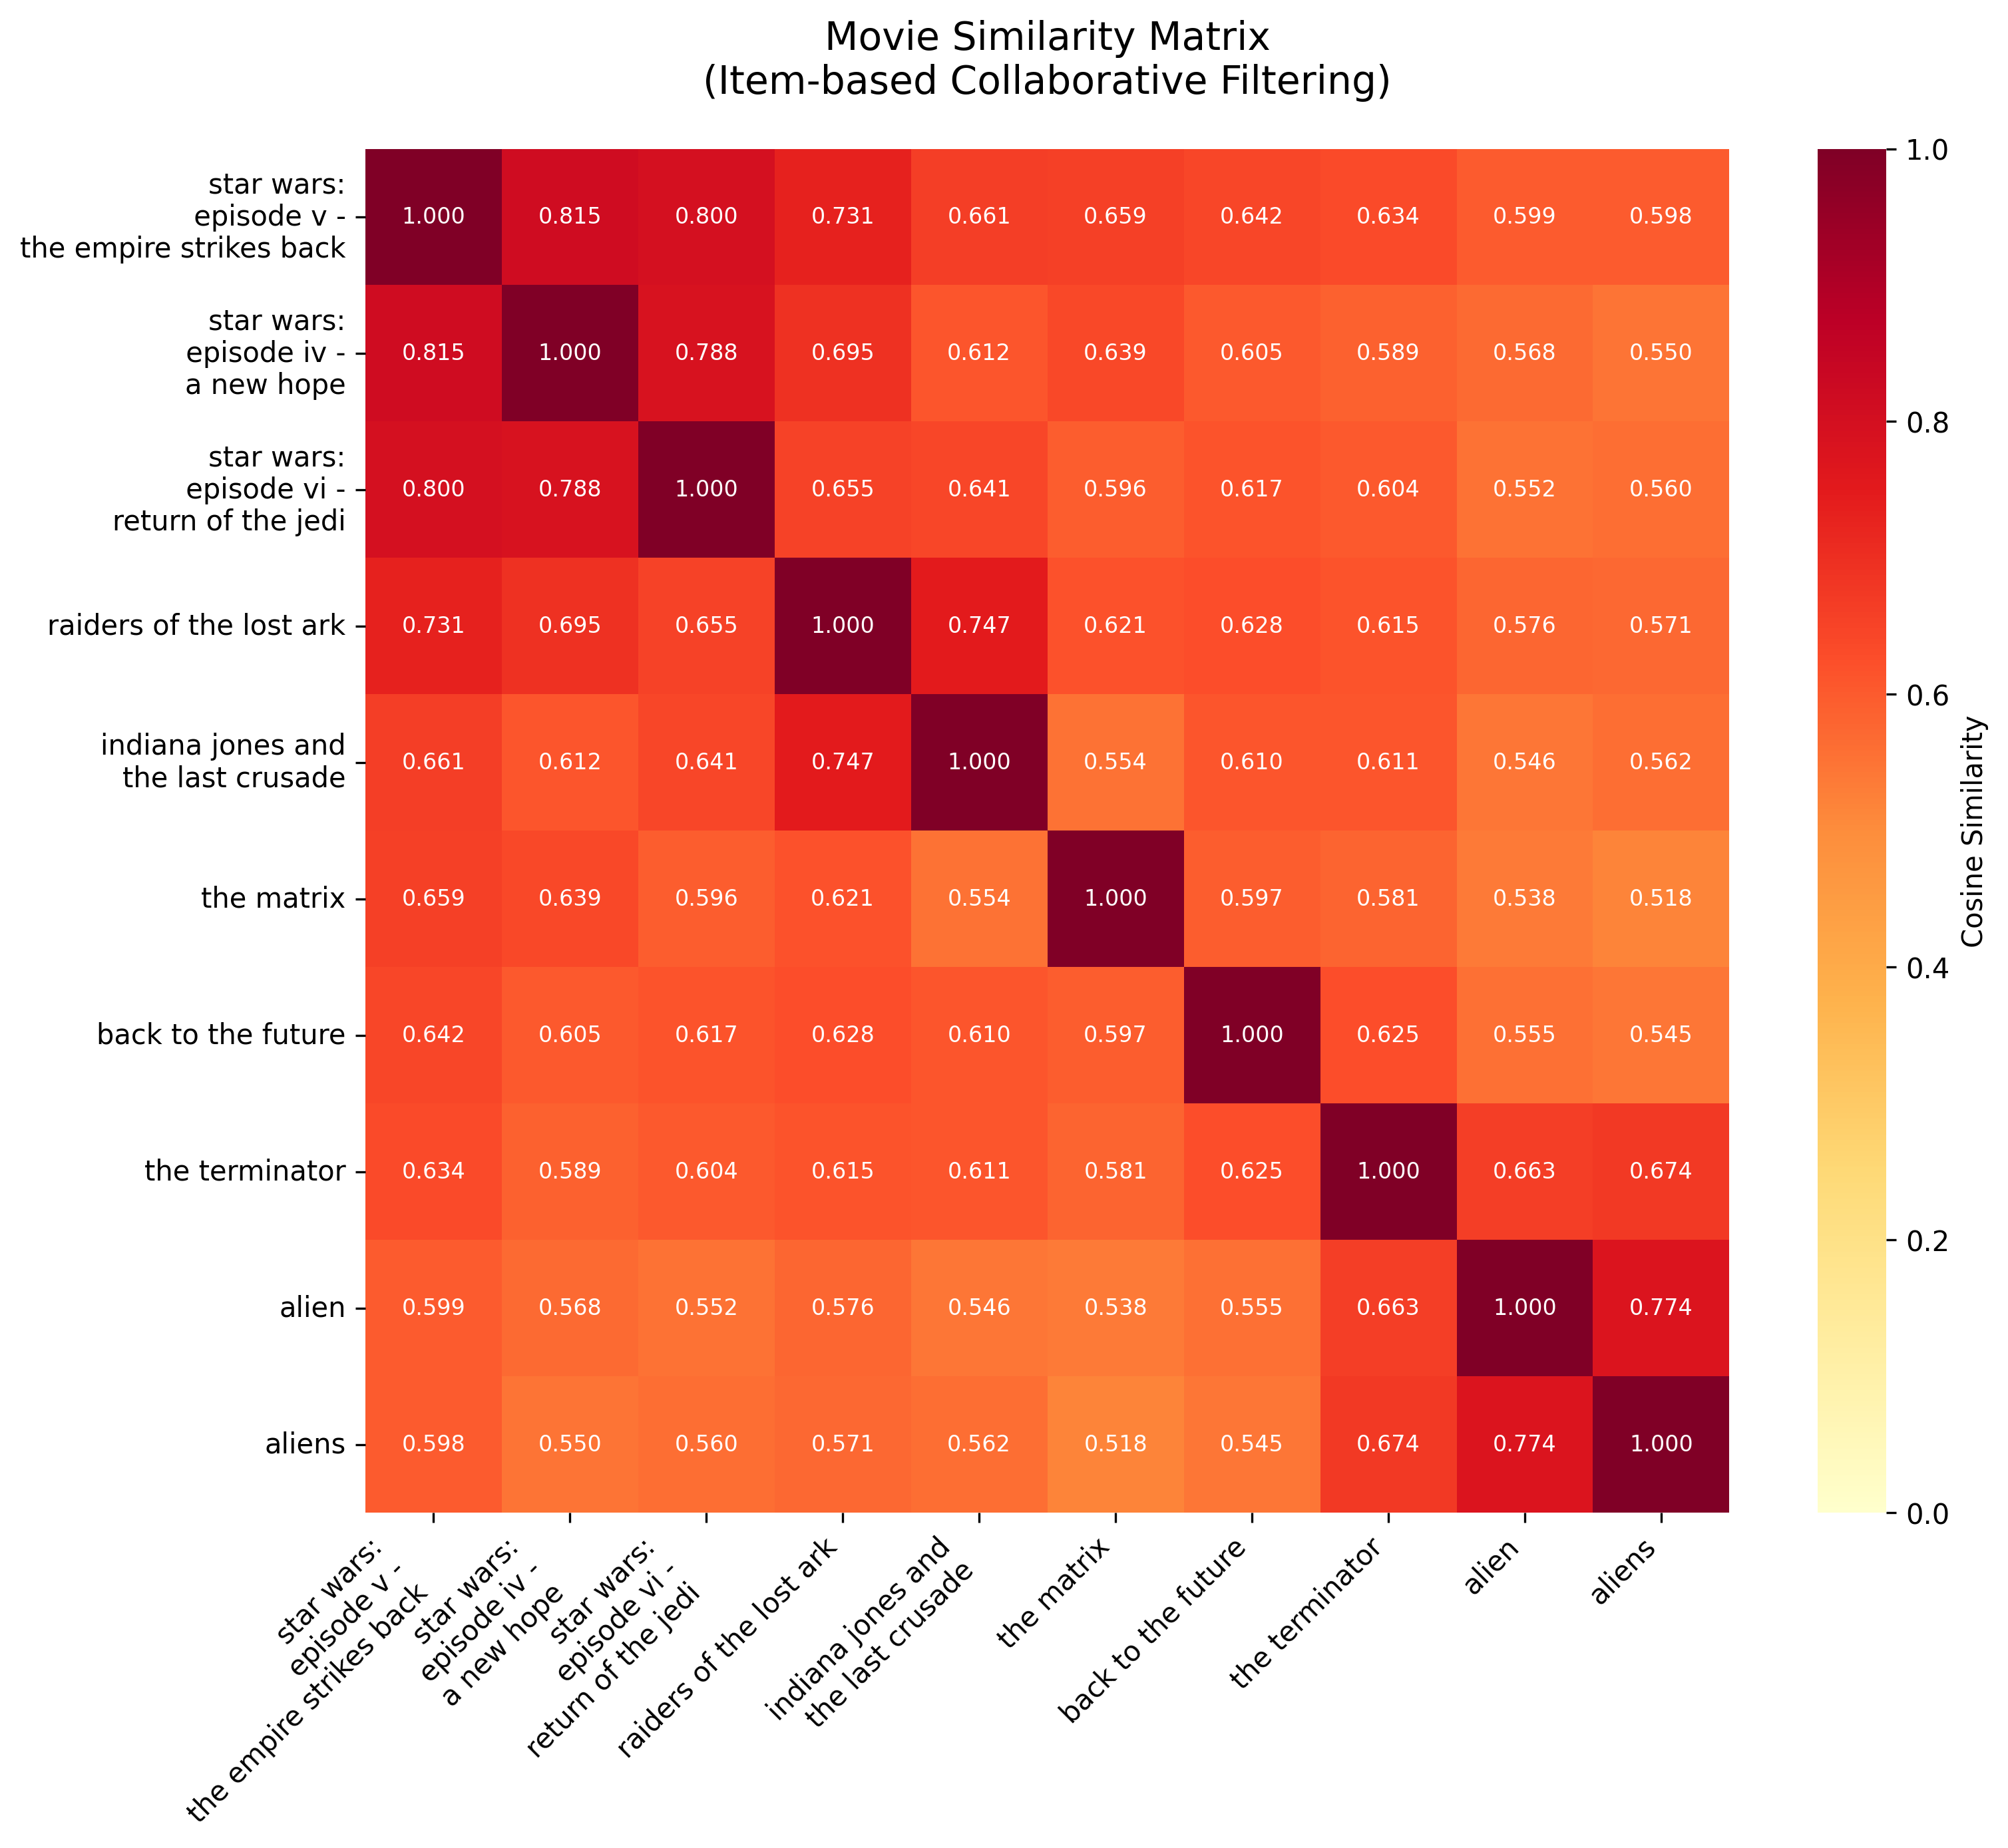

In [24]:
# Visualize collaborative filtering results
from pathlib import Path
from IPython.display import Image, display

# Show visualization images
image_files = list(analysis_dir.glob("*.png"))
if image_files:
    image_files = [img_file for img_file in image_files if img_file.name == "similarity_heatmap.png"]
    print(f"\n🖼️  Visualization plots ({len(image_files)} files):")
    for img_file in sorted(image_files):
        print(f"   {img_file.name}")
        display(Image(filename=str(img_file), width=800))